# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Heriswaya
- **Email:** heriswaya2014@gmail.com
- **ID Dicoding:** heriswaya_A5Dd

## Menentukan Pertanyaan Bisnis

- Bagaimana tren polusi udara dari waktu ke waktu di setiap stasiun?
- Stasiun mana yang memiliki rata-rata tingkat polusi tertinggi dan terendah?<br>

Analisis Lanjutan - Manual Grouping
- Bagaimana perbandingan tingkat polusi udara pada pagi, siang, sore, dan malam hari di setiap stasiun?

## Import Semua Packages/Library yang Digunakan

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Data Wrangling

### Gathering Data

In [172]:
aotizhongxin_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Aotizhongxin_20130301-20170228.csv")
aotizhongxin_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [173]:
changping_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Changping_20130301-20170228.csv")
changping_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [174]:
dingling_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Dingling_20130301-20170228.csv")
dingling_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


In [175]:
dongsi_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Dongsi_20130301-20170228.csv")
dongsi_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [176]:
guanyuan_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Guanyuan_20130301-20170228.csv")
guanyuan_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


In [177]:
gucheng_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Gucheng_20130301-20170228.csv")
gucheng_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


In [178]:
huairou_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Huairou_20130301-20170228.csv")
huairou_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


In [179]:
nongzhanguan_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Nongzhanguan_20130301-20170228.csv")
nongzhanguan_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,3,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan
3,4,2013,3,1,3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,N,4.9,Nongzhanguan
4,5,2013,3,1,4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Nongzhanguan


In [180]:
shunyi_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Shunyi_20130301-20170228.csv")
shunyi_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
2,3,2013,3,1,2,14.0,14.0,NaN,7.0,200.0,22.0,-1.7,1026.2,-23.0,0.0,NW,8.6,Shunyi
3,4,2013,3,1,3,12.0,12.0,3.0,5.0,NaN,NaN,-2.1,1027.3,-23.3,0.0,NW,6.6,Shunyi
4,5,2013,3,1,4,12.0,12.0,3.0,NaN,200.0,11.0,-2.4,1027.7,-22.9,0.0,NW,4.5,Shunyi


In [181]:
tiantan_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Tiantan_20130301-20170228.csv")
tiantan_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan


In [182]:
wanliu_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Wanliu_20130301-20170228.csv")
wanliu_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu
1,2,2013,3,1,1,9.0,9.0,6.0,28.0,400.0,50.0,-1.1,1023.2,-18.2,0.0,N,4.7,Wanliu
2,3,2013,3,1,2,3.0,6.0,NaN,19.0,400.0,55.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Wanliu
3,4,2013,3,1,3,11.0,30.0,8.0,14.0,NaN,NaN,-1.4,1024.5,-19.4,0.0,NW,3.1,Wanliu
4,5,2013,3,1,4,3.0,13.0,9.0,NaN,300.0,54.0,-2.0,1025.2,-19.5,0.0,N,2.0,Wanliu


In [183]:
wanshouxigong_df = pd.read_csv("https://raw.githubusercontent.com/heriswaya/Heriswaya-AnalisisAirQualityDataset/main/data/PRSA_Data_Wanshouxigong_20130301-20170228.csv")
wanshouxigong_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong


**Insight:**
- Bisa membantu mengetahui seperti apa kualitas udara pada setiap station
- Dapat membantu mengetahui kualitas udara berdasarkan parameter yang ada pada setiap tahun di setiap lokasi

### Assessing Data

#### Menilai tabel `aotizhongxin_df`

In [184]:
aotizhongxin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [185]:
aotizhongxin_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

In [186]:
print("Jumlah duplikasi: ", aotizhongxin_df.duplicated().sum())

Jumlah duplikasi:  0


In [187]:
aotizhongxin_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


#### Menilai tabel `changping_df`

In [188]:
changping_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34290 non-null  float64
 6   PM10     34482 non-null  float64
 7   SO2      34436 non-null  float64
 8   NO2      34397 non-null  float64
 9   CO       33543 non-null  float64
 10  O3       34460 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [189]:
changping_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       774
PM10        582
SO2         628
NO2         667
CO         1521
O3          604
TEMP         53
PRES         50
DEWP         53
RAIN         51
wd          140
WSPM         43
station       0
dtype: int64

In [190]:
print("Jumlah duplikasi: ", changping_df.duplicated().sum())

Jumlah duplikasi:  0


In [191]:
changping_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34290.000000,34482.000000,34436.000000,34397.000000,33543.000000,34460.000000,35011.000000,35014.000000,35011.000000,35013.000000,35021.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,71.099743,94.657871,14.958906,44.182086,1152.301345,57.940003,13.686111,1007.760278,1.505495,0.060366,1.853836
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.326926,83.441738,20.975331,29.519796,1103.056282,54.316674,11.365313,10.225664,13.822099,0.752899,1.309808
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.847700,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,18.000000,34.000000,2.000000,22.000000,500.000000,15.636600,3.400000,999.300000,-10.200000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,46.000000,72.000000,7.000000,36.000000,800.000000,46.000000,14.700000,1007.400000,1.800000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,100.000000,131.000000,18.000000,60.358200,1400.000000,80.000000,23.300000,1016.000000,14.200000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,882.000000,999.000000,310.000000,226.000000,10000.000000,429.000000,41.400000,1036.500000,27.200000,52.100000,10.000000


#### Menilai tabel `dingling_df`

In [192]:
dingling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34285 non-null  float64
 6   PM10     34408 non-null  float64
 7   SO2      34334 non-null  float64
 8   NO2      33830 non-null  float64
 9   CO       33052 non-null  float64
 10  O3       33850 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [193]:
dingling_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       779
PM10        656
SO2         730
NO2        1234
CO         2012
O3         1214
TEMP         53
PRES         50
DEWP         53
RAIN         51
wd          140
WSPM         43
station       0
dtype: int64

In [194]:
print("Jumlah duplikasi: ", dingling_df.duplicated().sum())

Jumlah duplikasi:  0


In [195]:
dingling_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34285.000000,34408.000000,34334.000000,33830.000000,33052.000000,33850.000000,35011.000000,35014.000000,35011.000000,35013.000000,35021.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,65.989497,83.739723,11.749650,27.585467,904.896073,68.548371,13.686111,1007.760278,1.505495,0.060366,1.853836
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.267723,79.541685,15.519259,26.383882,903.306220,53.764424,11.365313,10.225664,13.822099,0.752899,1.309808
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,14.000000,26.000000,2.000000,9.000000,300.000000,31.000000,3.400000,999.300000,-10.200000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,41.000000,60.000000,5.000000,19.000000,600.000000,61.000000,14.700000,1007.400000,1.800000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,93.000000,117.000000,15.000000,38.000000,1200.000000,90.000000,23.300000,1016.000000,14.200000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,881.000000,905.000000,156.000000,205.000000,10000.000000,500.000000,41.400000,1036.500000,27.200000,52.100000,10.000000


#### Menilai tabel `dongsi_df`

In [196]:
dongsi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34314 non-null  float64
 6   PM10     34511 non-null  float64
 7   SO2      34401 non-null  float64
 8   NO2      33463 non-null  float64
 9   CO       31867 non-null  float64
 10  O3       34400 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [197]:
dongsi_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       750
PM10        553
SO2         663
NO2        1601
CO         3197
O3          664
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

In [198]:
print("Jumlah duplikasi: ", dongsi_df.duplicated().sum())

Jumlah duplikasi:  0


In [199]:
dongsi_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34314.000000,34511.000000,34401.000000,33463.000000,31867.000000,34400.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,86.194297,110.336742,18.531107,53.699443,1330.069131,57.210637,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.575127,98.219860,22.905655,33.959230,1191.305887,58.033275,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.642600,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,4.000000,27.000000,600.000000,12.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,61.000000,86.000000,10.000000,47.000000,1000.000000,44.125200,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,119.000000,151.000000,24.000000,73.000000,1700.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,737.000000,955.000000,300.000000,258.000000,10000.000000,1071.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


#### Menilai tabel `guanyuan_df`

In [200]:
guanyuan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34448 non-null  float64
 6   PM10     34635 non-null  float64
 7   SO2      34590 non-null  float64
 8   NO2      34405 non-null  float64
 9   CO       33311 non-null  float64
 10  O3       33891 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [201]:
guanyuan_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       616
PM10        429
SO2         474
NO2         659
CO         1753
O3         1173
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

In [202]:
print("Jumlah duplikasi: ", guanyuan_df.duplicated().sum())

Jumlah duplikasi:  0


In [203]:
guanyuan_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34448.000000,34635.000000,34590.000000,34405.000000,33311.000000,33891.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.933372,109.023303,17.590941,57.901643,1271.294377,55.795044,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.933497,91.573709,23.600367,35.150857,1164.854945,57.436983,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,3.000000,31.000000,500.000000,7.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,89.000000,8.000000,51.000000,900.000000,41.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.000000,149.000000,22.000000,78.000000,1600.000000,81.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,680.000000,999.000000,293.000000,270.000000,10000.000000,415.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


#### Menilai tabel `gucheng_df`

In [204]:
gucheng_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34418 non-null  float64
 6   PM10     34683 non-null  float64
 7   SO2      34557 non-null  float64
 8   NO2      34396 non-null  float64
 9   CO       33663 non-null  float64
 10  O3       34335 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35013 non-null  float64
 14  RAIN     35021 non-null  float64
 15  wd       34905 non-null  object 
 16  WSPM     35022 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [205]:
gucheng_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       646
PM10        381
SO2         507
NO2         668
CO         1401
O3          729
TEMP         51
PRES         50
DEWP         51
RAIN         43
wd          159
WSPM         42
station       0
dtype: int64

In [206]:
print("Jumlah duplikasi: ", gucheng_df.duplicated().sum())

Jumlah duplikasi:  0


In [207]:
gucheng_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34418.000000,34683.000000,34557.000000,34396.000000,33663.000000,34335.000000,35013.000000,35014.000000,35013.000000,35021.000000,35022.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.852089,118.861978,15.366162,55.871075,1323.974423,57.694879,13.864524,1008.829592,2.610442,0.064453,1.343310
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.796445,96.742626,21.204526,36.473860,1208.957772,57.019587,11.292857,10.103256,13.782991,0.838654,1.151064
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-15.600000,984.000000,-34.600000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,24.000000,45.000000,2.000000,26.000000,600.000000,10.000000,3.600000,1000.500000,-8.900000,0.000000,0.600000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,99.000000,7.000000,50.000000,900.000000,45.000000,14.800000,1008.500000,3.000000,0.000000,1.000000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.750000,167.000000,20.000000,79.000000,1600.000000,83.000000,23.500000,1017.000000,15.300000,0.000000,1.800000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,770.000000,994.000000,500.000000,276.000000,10000.000000,450.000000,41.600000,1038.100000,27.400000,41.900000,12.000000


#### Menilai tabel `huairou_df`

In [208]:
huairou_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34111 non-null  float64
 6   PM10     34287 non-null  float64
 7   SO2      34084 non-null  float64
 8   NO2      33425 non-null  float64
 9   CO       33642 non-null  float64
 10  O3       33913 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35011 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35009 non-null  float64
 15  wd       34762 non-null  object 
 16  WSPM     35015 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [209]:
huairou_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       953
PM10        777
SO2         980
NO2        1639
CO         1422
O3         1151
TEMP         51
PRES         53
DEWP         53
RAIN         55
wd          302
WSPM         49
station       0
dtype: int64

In [210]:
print("Jumlah duplikasi: ", huairou_df.duplicated().sum())

Jumlah duplikasi:  0


In [211]:
huairou_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34111.000000,34287.000000,34084.000000,33425.000000,33642.000000,33913.000000,35013.000000,35011.000000,35011.000000,35009.000000,35015.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,69.626367,91.482690,12.121553,32.497250,1022.554545,59.824713,12.445426,1007.598568,2.238619,0.067940,1.652021
std,10122.249256,1.177213,3.448752,8.800218,6.922285,71.224916,83.289578,18.896912,26.489531,898.738241,54.605746,11.751103,10.022101,14.052541,0.849046,1.199143
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,17.000000,28.000000,2.000000,12.000000,400.000000,18.000000,2.100000,999.300000,-9.600000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,47.000000,69.000000,4.000000,25.000000,800.000000,49.000000,13.600000,1007.300000,2.700000,0.000000,1.300000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,98.000000,131.000000,14.000000,46.000000,1300.000000,83.000000,22.300000,1015.500000,15.300000,0.000000,2.000000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,762.000000,993.000000,315.000000,231.000000,10000.000000,444.000000,40.300000,1036.500000,29.100000,45.900000,12.900000


#### Menilai tabel `nongzhanguan_df`

In [212]:
nongzhanguan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34436 non-null  float64
 6   PM10     34624 non-null  float64
 7   SO2      34618 non-null  float64
 8   NO2      34372 non-null  float64
 9   CO       33858 non-null  float64
 10  O3       34558 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [213]:
nongzhanguan_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       628
PM10        440
SO2         446
NO2         692
CO         1206
O3          506
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

In [214]:
print("Jumlah duplikasi: ", nongzhanguan_df.duplicated().sum())

Jumlah duplikasi:  0


In [215]:
nongzhanguan_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34436.000000,34624.000000,34618.000000,34372.000000,33858.000000,34558.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,84.838483,108.991096,18.689242,58.097172,1324.350198,58.534682,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.225344,95.341177,24.280665,36.297740,1245.166124,58.401448,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.571200,2.000000,100.000000,0.214200,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,29.000000,500.000000,10.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,9.000000,51.000000,900.000000,45.000000,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,149.000000,23.000000,80.000000,1600.000000,84.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,844.000000,995.000000,257.000000,273.000000,10000.000000,390.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


#### Menilai tabel `shunyi_df`

In [216]:
shunyi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34151 non-null  float64
 6   PM10     34516 non-null  float64
 7   SO2      33768 non-null  float64
 8   NO2      33699 non-null  float64
 9   CO       32886 non-null  float64
 10  O3       33575 non-null  float64
 11  TEMP     35013 non-null  float64
 12  PRES     35013 non-null  float64
 13  DEWP     35010 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34581 non-null  object 
 16  WSPM     35020 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [217]:
shunyi_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       913
PM10        548
SO2        1296
NO2        1365
CO         2178
O3         1489
TEMP         51
PRES         51
DEWP         54
RAIN         51
wd          483
WSPM         44
station       0
dtype: int64

In [218]:
print("Jumlah duplikasi: ", shunyi_df.duplicated().sum())

Jumlah duplikasi:  0


In [219]:
shunyi_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34151.000000,34516.000000,33768.000000,33699.000000,32886.000000,33575.000000,35013.000000,35013.000000,35010.000000,35013.000000,35020.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.491602,98.737026,13.572039,43.908865,1187.063979,55.201321,13.387969,1013.061938,2.465036,0.061094,1.807533
std,10122.249256,1.177213,3.448752,8.800218,6.922285,81.231739,89.143718,19.572068,30.996828,1156.374102,54.873726,11.483588,10.177339,13.726622,0.761668,1.287817
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,988.000000,-36.000000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,19.000000,31.000000,2.000000,19.000000,400.000000,10.000000,3.000000,1004.700000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,77.000000,5.000000,37.000000,800.000000,43.000000,14.400000,1012.700000,3.100000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,112.000000,138.000000,17.000000,62.000000,1500.000000,77.000000,23.200000,1021.000000,15.100000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,941.000000,999.000000,239.000000,258.000000,10000.000000,351.716400,40.600000,1042.800000,27.500000,37.300000,12.800000


#### Menilai tabel `tiantan_df`

In [220]:
tiantan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34387 non-null  float64
 6   PM10     34467 non-null  float64
 7   SO2      33946 non-null  float64
 8   NO2      34320 non-null  float64
 9   CO       33938 non-null  float64
 10  O3       34221 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [221]:
tiantan_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       677
PM10        597
SO2        1118
NO2         744
CO         1126
O3          843
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           78
WSPM         14
station       0
dtype: int64

In [222]:
print("Jumlah duplikasi: ", tiantan_df.duplicated().sum())

Jumlah duplikasi:  0


In [223]:
tiantan_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34387.000000,34467.000000,33946.000000,34320.000000,33938.000000,34221.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.164911,106.363672,14.367615,53.162646,1298.303318,55.984297,13.671490,1012.547419,2.447535,0.064020,1.860785
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.921384,89.700157,20.144631,31.946224,1170.593297,59.081528,11.458418,10.266059,13.810696,0.786282,1.280368
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.571200,2.000000,100.000000,0.428400,-16.800000,987.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,41.000000,3.000000,28.000000,500.000000,8.000000,3.100000,1004.000000,-8.800000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,7.000000,47.000000,900.000000,40.000000,14.600000,1012.200000,3.000000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,113.000000,144.000000,17.000000,71.000000,1600.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,2.400000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,821.000000,988.000000,273.000000,241.000000,10000.000000,674.000000,41.100000,1042.000000,28.800000,46.400000,10.500000


#### Menilai tabel `wanliu_df`

In [224]:
wanliu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34682 non-null  float64
 6   PM10     34780 non-null  float64
 7   SO2      34489 non-null  float64
 8   NO2      33994 non-null  float64
 9   CO       33252 non-null  float64
 10  O3       32957 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34941 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [225]:
wanliu_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       382
PM10        284
SO2         575
NO2        1070
CO         1812
O3         2107
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd          123
WSPM         14
station       0
dtype: int64

In [226]:
print("Jumlah duplikasi: ", wanliu_df.duplicated().sum())

Jumlah duplikasi:  0


In [227]:
wanliu_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34682.000000,34780.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.374716,110.464618,18.376481,65.258789,1319.353513,48.873614,13.428865,1011.097536,3.266588,0.068263,1.501215
std,10122.249256,1.177213,3.448752,8.800218,6.922285,81.905568,92.795065,22.609648,37.996088,1268.114331,55.111740,11.346931,10.355247,13.678060,0.896726,1.104472
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.642400,100.000000,0.214200,-15.800000,985.900000,-34.900000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,4.000000,36.000000,500.000000,4.000000,3.200000,1002.500000,-8.100000,0.000000,0.800000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,88.000000,10.000000,60.000000,900.000000,32.000000,14.300000,1010.800000,4.000000,0.000000,1.200000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,153.000000,23.000000,88.000000,1600.000000,73.000000,22.900000,1019.400000,15.800000,0.000000,2.000000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,957.000000,951.000000,282.000000,264.000000,10000.000000,364.000000,40.500000,1040.300000,28.500000,72.500000,11.200000


#### Menilai tabel `wanshouxigong_df`

In [228]:
wanshouxigong_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34368 non-null  float64
 6   PM10     34580 non-null  float64
 7   SO2      34395 non-null  float64
 8   NO2      34310 non-null  float64
 9   CO       33767 non-null  float64
 10  O3       33986 non-null  float64
 11  TEMP     35045 non-null  float64
 12  PRES     35045 non-null  float64
 13  DEWP     35045 non-null  float64
 14  RAIN     35045 non-null  float64
 15  wd       34985 non-null  object 
 16  WSPM     35051 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


In [229]:
wanshouxigong_df.isna().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       696
PM10        484
SO2         669
NO2         754
CO         1297
O3         1078
TEMP         19
PRES         19
DEWP         19
RAIN         19
wd           79
WSPM         13
station       0
dtype: int64

In [230]:
print("Jumlah duplikasi: ", wanshouxigong_df.duplicated().sum())

Jumlah duplikasi:  0


In [231]:
wanshouxigong_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34368.000000,34580.000000,34395.000000,34310.00000,33767.000000,33986.000000,35045.000000,35045.000000,35045.000000,35045.000000,35051.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,85.024136,112.223459,17.148603,55.52956,1370.395031,56.229904,13.784477,1011.511804,2.707442,0.064320,1.745314
std,10122.249256,1.177213,3.448752,8.800218,6.922285,85.975981,97.593210,23.940834,35.80805,1223.139114,57.082710,11.385156,10.570928,13.704139,0.796981,1.206355
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.00000,100.000000,0.214200,-16.800000,985.100000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,39.000000,3.000000,28.00000,600.000000,8.000000,3.400000,1002.800000,-8.500000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,91.000000,8.000000,49.00000,1000.000000,42.000000,14.800000,1011.000000,3.300000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,154.000000,21.000000,77.00000,1700.000000,82.000000,23.500000,1020.000000,15.200000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,961.000000,411.000000,251.00000,9800.000000,358.000000,40.600000,1042.000000,28.500000,46.400000,13.200000


#### **Insight:**
- Mengetahui apakah dataset bersih atau perlu diperbaiki (missing values, duplikasi)
- Memberikan informasi tentang jumlah baris & kolom dan tipe data pada setiap station
- Memberikan rangkuman statistik seperti mean, median, min, max, standar deviasi, dll. pada setiap station

### Cleaning Data
---
Terlihat pada gathering data di atas, tidak ada tabel yang memiliki duplikasi data. Hanya ada data yang kosong, sehingga data yang kosong tersebut akan diisi dengan cara:
- mode (nilai yang sering muncul) untuk `wd` karena kategorikal.
- interpolate untuk data float (PM2.5, PM10, dst) karena cocok untuk data time-series.

#### Membersihkan tabel `aotizhongxin_df`

Missing values

In [232]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
aotizhongxin_df['wd'] = aotizhongxin_df['wd'].fillna(aotizhongxin_df['wd'].mode()[0])

In [233]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_aotizhongxin = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
aotizhongxin_df[float_columns_aotizhongxin] = aotizhongxin_df[float_columns_aotizhongxin].interpolate()

In [234]:
# Cek
aotizhongxin_df.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

#### Membersihkan tabel `changping_df`

Missing values

In [235]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
changping_df['wd'] = changping_df['wd'].fillna(changping_df['wd'].mode()[0])

In [236]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_changping = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
changping_df[float_columns_changping] = changping_df[float_columns_changping].interpolate()

In [237]:
# Cek
changping_df.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

#### Membersihkan tabel `dingling_df`

Missing values

In [238]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
dingling_df['wd'] = dingling_df['wd'].fillna(dingling_df['wd'].mode()[0])

In [239]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_dingling = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
dingling_df[float_columns_dingling] = dingling_df[float_columns_dingling].interpolate()

In [240]:
# Cek
dingling_df.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        2
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

In [241]:
# Masih ada data yang kosong, shg akan digunakan `Forward/Backward Fill`
dingling_df['NO2'] = dingling_df['NO2'].ffill().bfill()

In [242]:
print(dingling_df['NO2'].isna().sum())  # Cek apakah masih ada NaN

0


#### Membersihkan tabel `dongsi_df`

Missing values

In [243]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
dongsi_df['wd'] = dongsi_df['wd'].fillna(dongsi_df['wd'].mode()[0])

In [244]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_dongsi = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
dongsi_df[float_columns_dongsi] = dongsi_df[float_columns_dongsi].interpolate()

In [245]:
# Cek
dongsi_df.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

#### Membersihkan tabel `guanyuan_df`

Missing values

In [246]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
guanyuan_df['wd'] = guanyuan_df['wd'].fillna(guanyuan_df['wd'].mode()[0])

In [247]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_guanyuan = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
guanyuan_df[float_columns_guanyuan] = guanyuan_df[float_columns_guanyuan].interpolate()

In [248]:
# Cek
guanyuan_df.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

#### Membersihkan tabel `gucheng_df`

Missing values

In [249]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
gucheng_df['wd'] = gucheng_df['wd'].fillna(gucheng_df['wd'].mode()[0])

In [250]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_gucheng = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
gucheng_df[float_columns_gucheng] = gucheng_df[float_columns_gucheng].interpolate()

In [251]:
# Cek
gucheng_df.isna().sum()

No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2        20
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
dtype: int64

#### Membersihkan tabel `huairou_df`

Missing values

In [252]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
huairou_df['wd'] = huairou_df['wd'].fillna(huairou_df['wd'].mode()[0])

In [253]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_huairou = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
huairou_df[float_columns_huairou] = huairou_df[float_columns_huairou].interpolate()

In [254]:
# Cek
huairou_df.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

#### Membersihkan tabel `nongzhanguan_df`

Missing values

In [255]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
nongzhanguan_df['wd'] = nongzhanguan_df['wd'].fillna(nongzhanguan_df['wd'].mode()[0])

In [256]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_nongzhanguan = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
nongzhanguan_df[float_columns_nongzhanguan] = nongzhanguan_df[float_columns_nongzhanguan].interpolate()

In [257]:
# Cek
nongzhanguan_df.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

#### Membersihkan tabel `shunyi_df`

Missing values

In [258]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
shunyi_df['wd'] = shunyi_df['wd'].fillna(shunyi_df['wd'].mode()[0])

In [259]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_shunyi = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
shunyi_df[float_columns_shunyi] = shunyi_df[float_columns_shunyi].interpolate()

In [260]:
# Cek
shunyi_df.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

#### Membersihkan tabel `tiantan_df`

Missing values

In [261]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
tiantan_df['wd'] = tiantan_df['wd'].fillna(tiantan_df['wd'].mode()[0])

In [262]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_tiantan = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
tiantan_df[float_columns_tiantan] = tiantan_df[float_columns_tiantan].interpolate()

In [263]:
# Cek
tiantan_df.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

#### Membersihkan tabel `wanliu_df`

Missing values

In [264]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
wanliu_df['wd'] = wanliu_df['wd'].fillna(wanliu_df['wd'].mode()[0])

In [265]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_wanliu = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
wanliu_df[float_columns_wanliu] = wanliu_df[float_columns_wanliu].interpolate()

In [266]:
# Cek
wanliu_df.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

#### Membersihkan tabel `wanshouxigong_df`

Missing values

In [267]:
# wd (wind direction) bisa menggunakan mode (nilai yang paling sering muncul)
wanshouxigong_df['wd'] = wanshouxigong_df['wd'].fillna(wanshouxigong_df['wd'].mode()[0])

In [268]:
# interpolate() akan mengisi missing values berdasarkan pola data sebelum dan sesudahnya.
# Daftar kolom yang akan diinterpolasi
float_columns_wanshouxigong = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi untuk setiap kolom
wanshouxigong_df[float_columns_wanshouxigong] = wanshouxigong_df[float_columns_wanshouxigong].interpolate()

In [269]:
# Cek
wanshouxigong_df.isna().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

#### **Insight:**
- Tren polusi udara lebih jelas dan tidak terdistorsi.
- Tidak ada lagi missing values, dataset lebih siap untuk analisis lanjutan.

## Exploratory Data Analysis (EDA)

### Explore `aotizhongxin_df`

In [270]:
print(aotizhongxin_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10   SO2    NO2      CO  \
19355  19356  2015      5   16    11   22.0   47.0   7.0   46.0   500.0   
31583  31584  2016     10    6    23   42.0   42.0   2.0   32.0   700.0   
27732  27733  2016      4   29    12  144.0  160.0  33.0   37.0  1900.0   
15115  15116  2014     11   20    19  296.0  401.0  25.0  175.0  3500.0   
3370    3371  2013      7   19    10  150.0  127.0  12.0   74.0  1000.0   
2615    2616  2013      6   17    23   51.0   66.0   9.0   92.0   700.0   
11457  11458  2014      6   21     9   82.0   82.0   3.0   64.0   800.0   
10270  10271  2014      5    2    22   30.0   71.0   2.0   99.0   500.0   
21914  21915  2015      8   31     2   45.0   45.0   2.0   32.0   900.0   
5874    5875  2013     10   31    18  168.0  191.0  19.0  135.0  1600.0   

             O3  TEMP    PRES  DEWP  RAIN   wd  WSPM       station  
19355   85.0000  25.7  1006.9   0.3   0.0    W   1.3  Aotizhongxin  
31583   36.0000  14.3  1020.6  13.2 

In [271]:
print(aotizhongxin_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

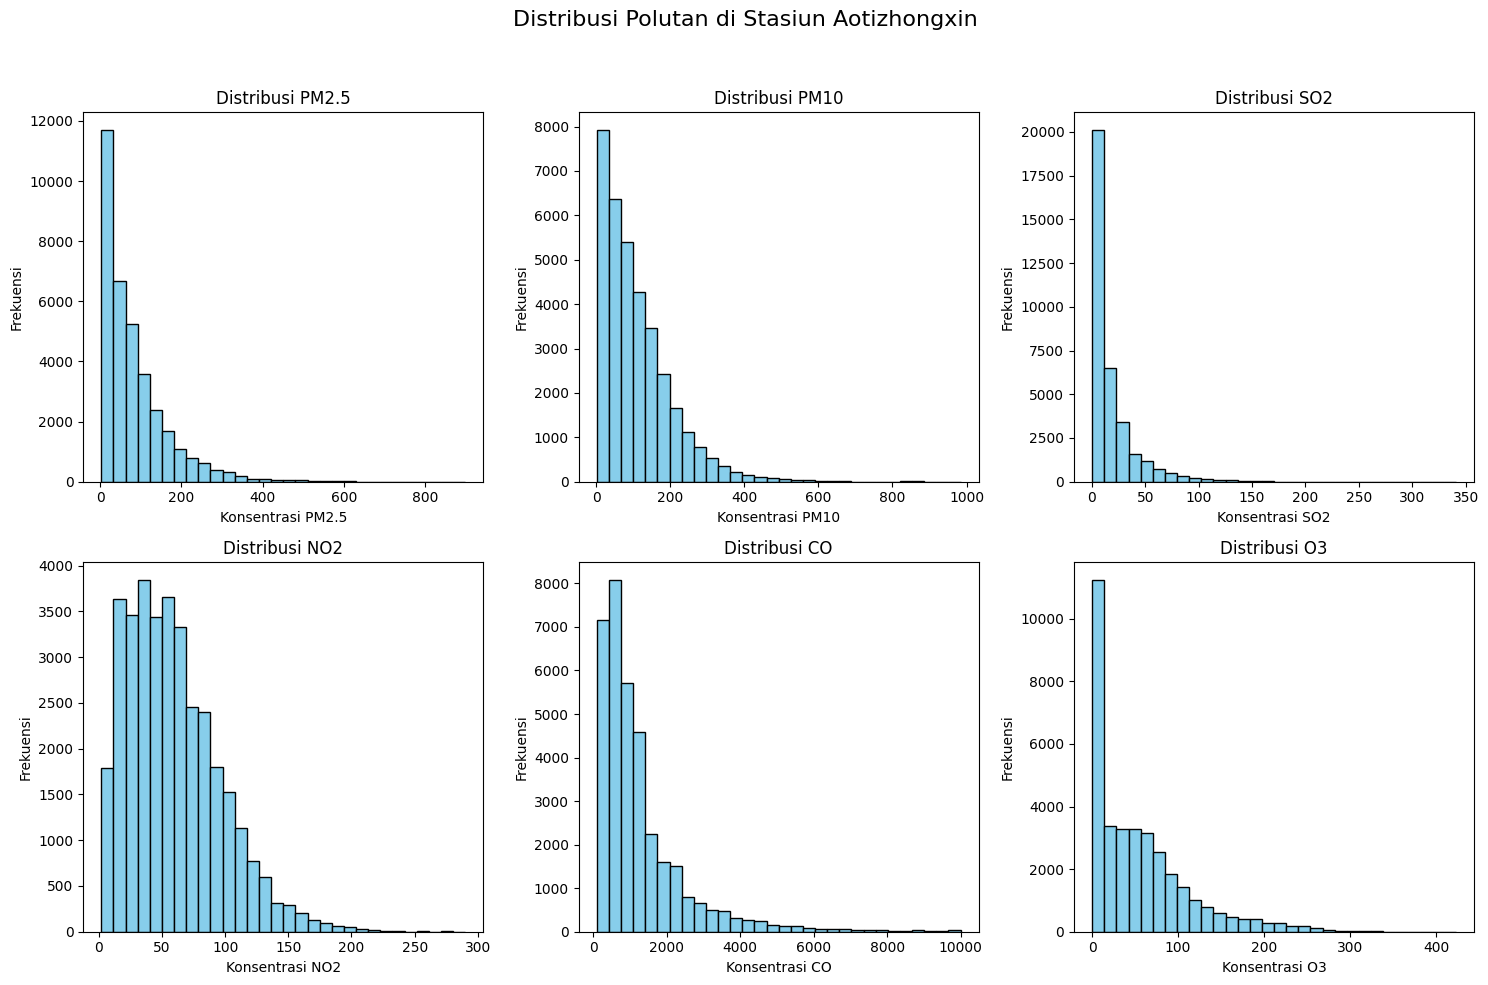

In [272]:
# Histogram untuk melihat sebaran polutan.
pollutants_aotizhongxin = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun Aotizhongxin", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_aotizhongxin):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(aotizhongxin_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

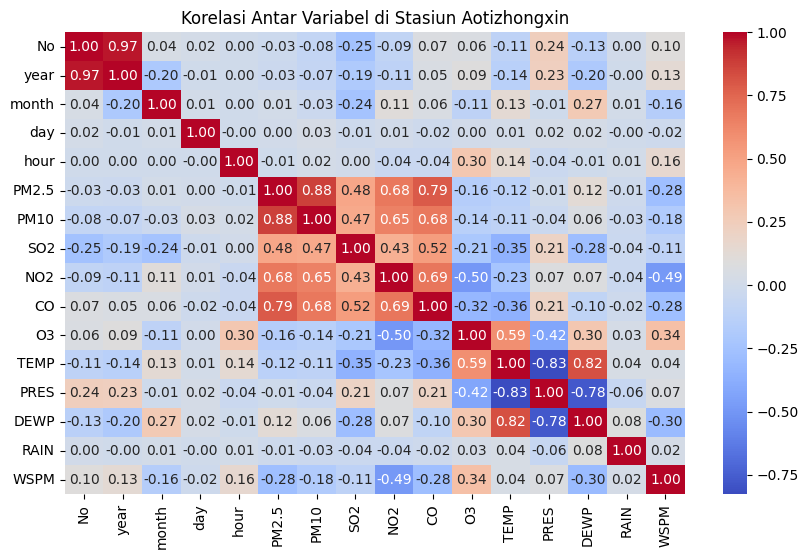

In [273]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_aotizhongxin = aotizhongxin_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(aotizhongxin_df[num_cols_aotizhongxin].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun Aotizhongxin')
plt.show()

### Explore `changping_df`

In [274]:
print(changping_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10   SO2    NO2      CO  \
10924  10925  2014      5   30     4   37.0   80.0  12.0   66.0   900.0   
648      649  2013      3   28     0    6.0   11.0   3.0    7.0   400.0   
21193  21194  2015      8    1     1   34.0   41.0   2.0   10.0   400.0   
321      322  2013      3   14     9   98.0  121.0  58.0   67.0  1800.0   
6900    6901  2013     12   13    12   43.0   43.0  37.0   35.0   900.0   
7674    7675  2014      1   14    18  132.0  222.0  89.0  109.0  2500.0   
17343  17344  2015      2   21    15  188.0  188.0  13.0   35.0  1900.0   
13100  13101  2014      8   28    20   90.0  108.0   2.0   34.0   800.0   
25092  25093  2016      1   10    12   57.0   68.0  25.0   71.0  1600.0   
9618    9619  2014      4    5    18   13.0   42.0  10.0   15.0   300.0   

          O3  TEMP    PRES  DEWP  RAIN   wd  WSPM    station  
10924   44.0  23.3   996.6   8.2   0.0  NNW   1.2  Changping  
648     84.0   7.2  1010.8 -18.6   0.0    E   3.

In [275]:
print(changping_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

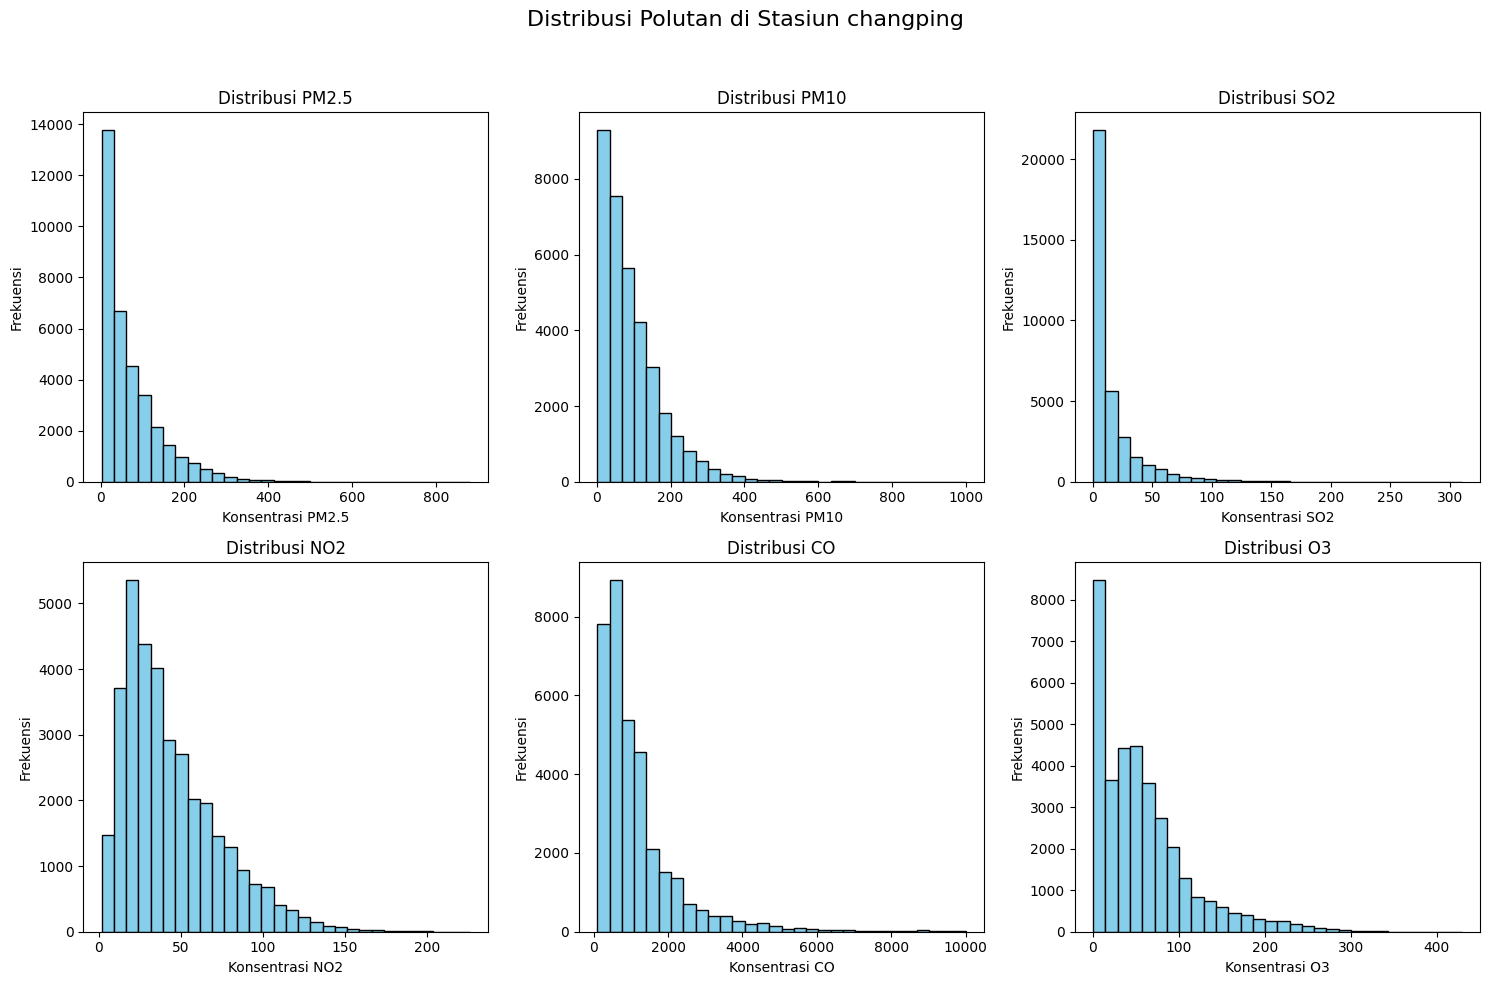

In [276]:
# Histogram untuk melihat sebaran polutan.
pollutants_changping = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun changping", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_changping):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(changping_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

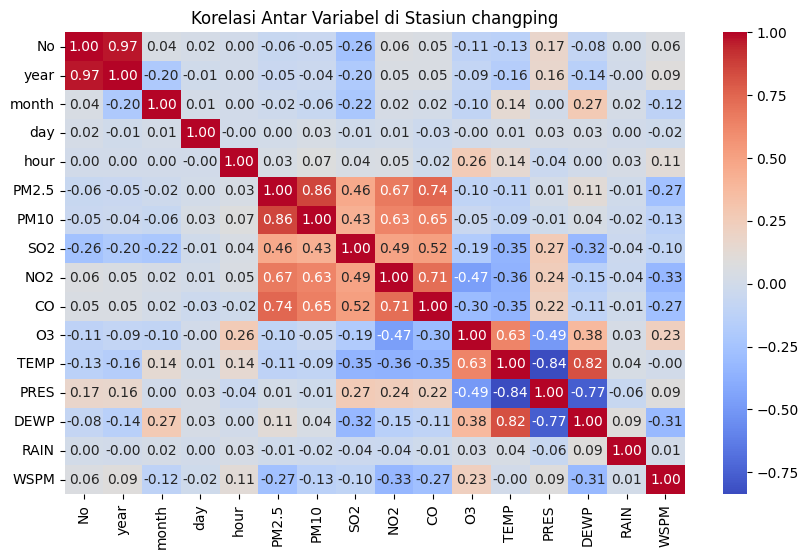

In [277]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_changping = changping_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(changping_df[num_cols_changping].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun changping')
plt.show()

### Explore `dingling_df`

In [278]:
print(dingling_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10   SO2   NO2      CO  \
28202  28203  2016      5   19     2   66.0   99.0   2.0  27.0   400.0   
7287    7288  2013     12   29    15   19.0   48.0  23.0  16.0   400.0   
19223  19224  2015      5   10    23   30.0   30.0   2.0  30.0  1200.0   
32168  32169  2016     10   31     8    3.0    7.0   2.0   2.0   100.0   
17128  17129  2015      2   12    16   28.0   37.0  15.0  36.0   600.0   
24887  24888  2016      1    1    23  145.0  145.0  22.0  82.0  4200.0   
11        12  2013      3    1    11    3.0    2.0   3.0   2.0   200.0   
10390  10391  2014      5    7    22   22.0   53.0   2.0  12.0   100.0   
20360  20361  2015      6   27     8   55.0   82.0   2.0  12.0   300.0   
2383    2384  2013      6    8     7  100.0   74.0   3.0  13.0  1550.0   

            O3  TEMP    PRES  DEWP  RAIN   wd  WSPM   station  
28202  93.0000  19.3  1004.2  13.2   0.0  ENE   0.7  Dingling  
7287   64.0000   6.7  1006.6 -19.0   0.0    W   4.2  Ding

In [279]:
print(dingling_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

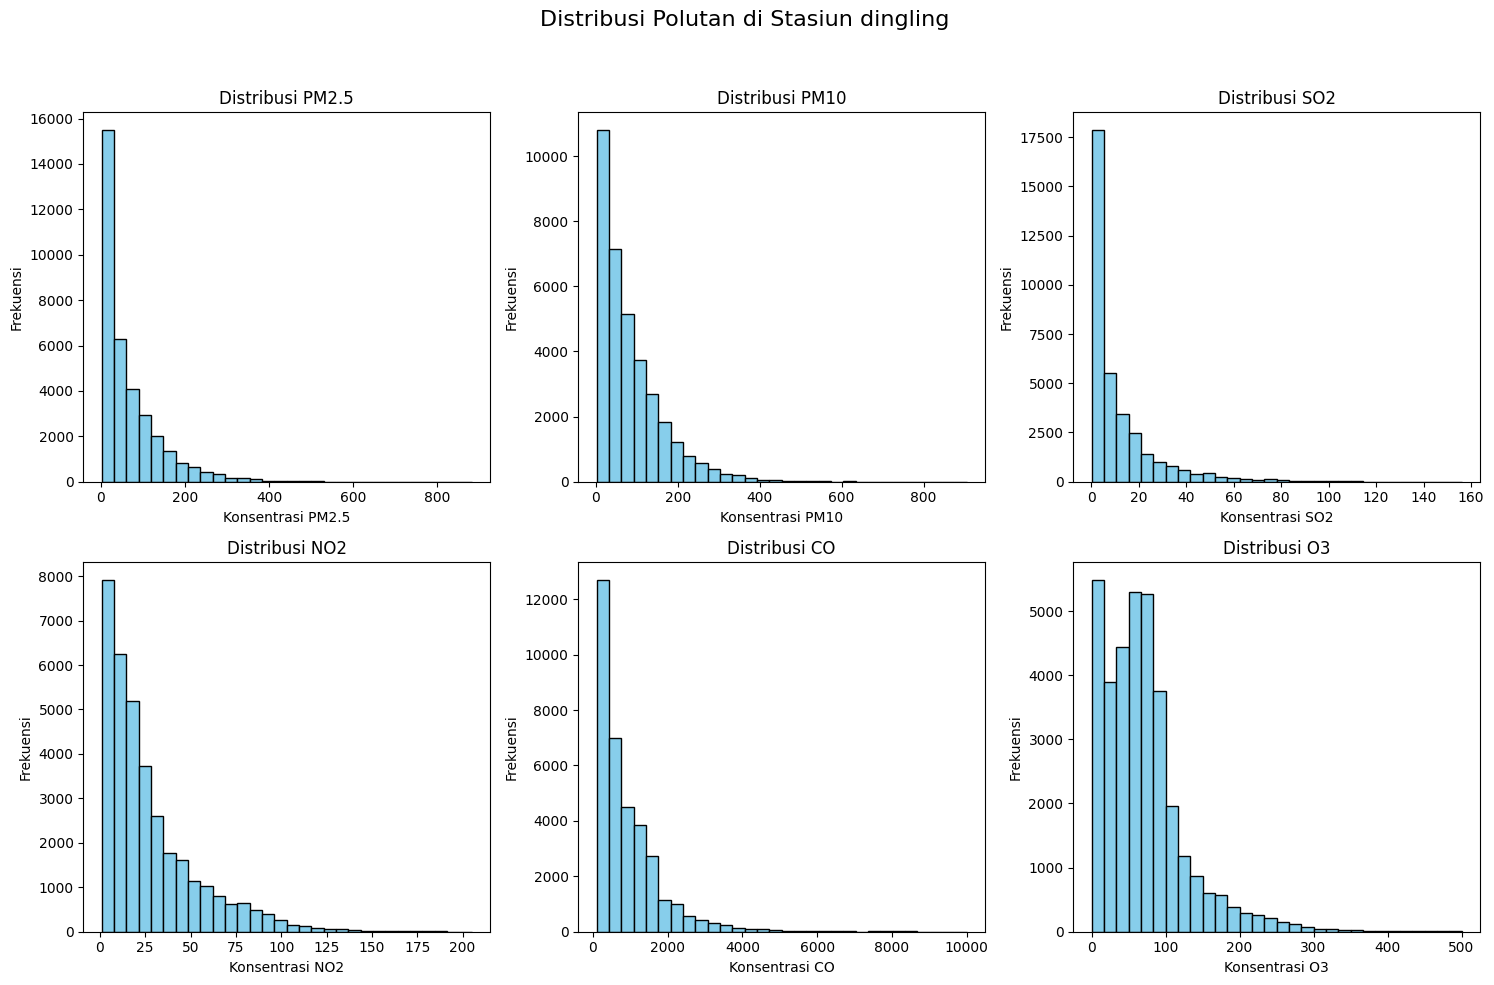

In [280]:
# Histogram untuk melihat sebaran polutan.
pollutants_dingling = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun dingling", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_dingling):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(dingling_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

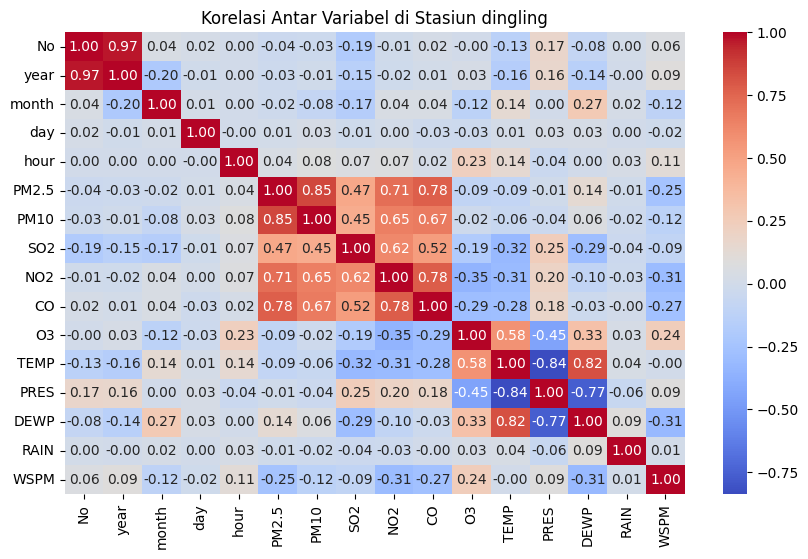

In [281]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_dingling = dingling_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(dingling_df[num_cols_dingling].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun dingling')
plt.show()

### Explore `dongsi_df`

In [282]:
print(dongsi_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10    SO2    NO2      CO  \
8794    8795  2014      3    2    10  135.0  167.0  112.0   67.0  3300.0   
13663  13664  2014      9   21     7   66.0   76.0   32.0   59.0  2500.0   
12580  12581  2014      8    7     4  100.0  100.0   11.0   68.0  1300.0   
13124  13125  2014      8   29    20  106.0  133.0    7.0   48.0  1200.0   
18514  18515  2015      4   11    10  187.0  187.0   39.0   42.0  2400.0   
10813  10814  2014      5   25    13   21.0   82.0    2.0    7.0   200.0   
14307  14308  2014     10   18     3  147.0  240.0   11.0  148.0  1900.0   
11302  11303  2014      6   14    22   79.0  131.0    5.0   63.0  1200.0   
19140  19141  2015      5    7    12   72.0  117.0    8.0   35.0   600.0   
11913  11914  2014      7   10     9   23.0   23.0   14.0   58.0   800.0   

          O3  TEMP    PRES  DEWP  RAIN   wd  WSPM station  
8794    34.0   3.4  1019.9  -6.1   0.0  ENE   2.5  Dongsi  
13663   25.0  19.4  1013.5  13.3   0.0    E

In [283]:
print(dongsi_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

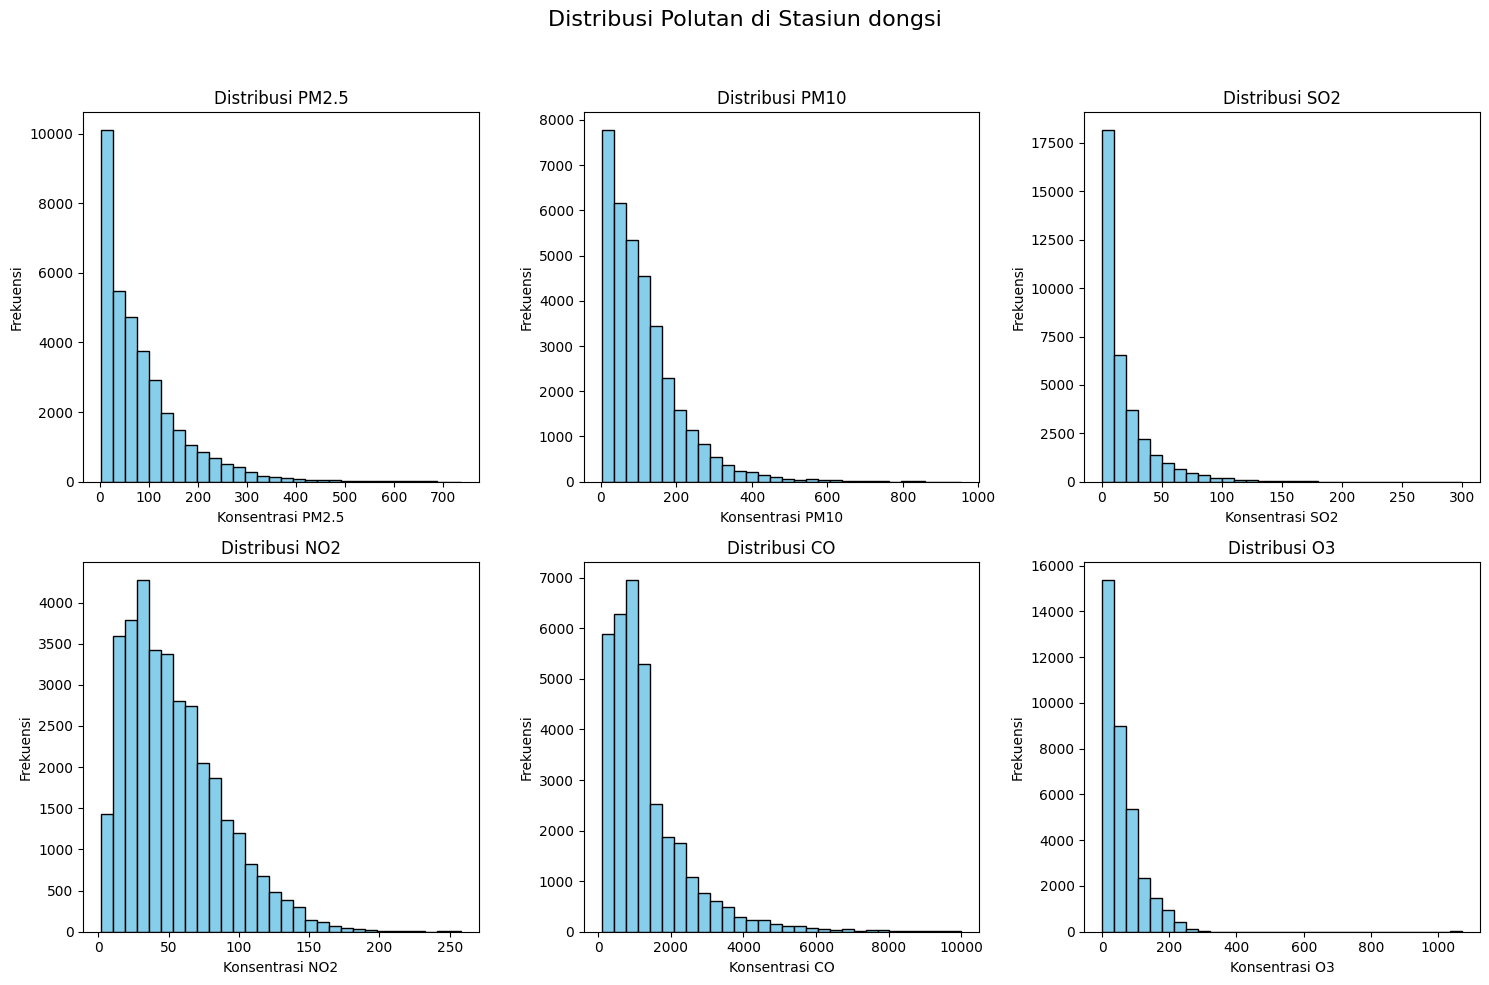

In [284]:
# Histogram untuk melihat sebaran polutan.
pollutants_dongsi = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun dongsi", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_dongsi):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(dongsi_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

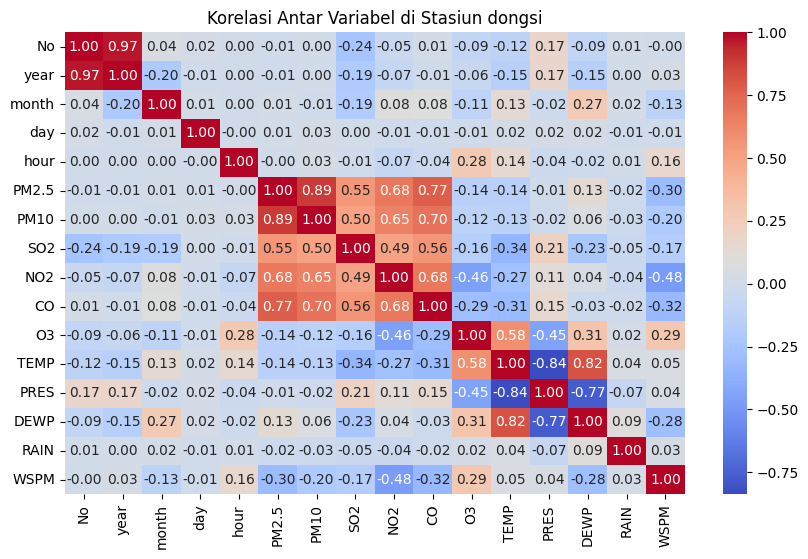

In [285]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_dongsi = dongsi_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(dongsi_df[num_cols_dongsi].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun dongsi')
plt.show()

### Explore `guanyuan_df`

In [286]:
print(guanyuan_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10    SO2    NO2      CO  \
24644  24645  2015     12   22    20  460.0  489.0   25.0  132.0  7900.0   
8817    8818  2014      3    3     9  209.0  237.0  165.0  104.0  5700.0   
19664  19665  2015      5   29     8  114.0  121.0    3.0   77.0  1400.0   
17485  17486  2015      2   27    13   24.0   36.0   25.0   43.0  1000.0   
25364  25365  2016      1   21    20  138.0  148.0   26.0   75.0  2700.0   
9446    9447  2014      3   29    14   27.0   29.0    4.0   18.0   100.0   
24791  24792  2015     12   28    23  223.0  227.0   37.0  118.0  2600.0   
2512    2513  2013      6   13    16  108.0  123.0   39.0   20.0  1500.0   
10479  10480  2014      5   11    15    9.0    9.0    2.0   29.0   700.0   
12116  12117  2014      7   18    20  105.0  105.0    2.0   24.0  1000.0   

          O3  TEMP    PRES  DEWP  RAIN   wd  WSPM   station  
24644    3.0  -1.1  1022.7  -1.1   0.0    E   1.1  Guanyuan  
8817     2.0   3.1  1017.0  -2.4   0.0 

In [287]:
print(guanyuan_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

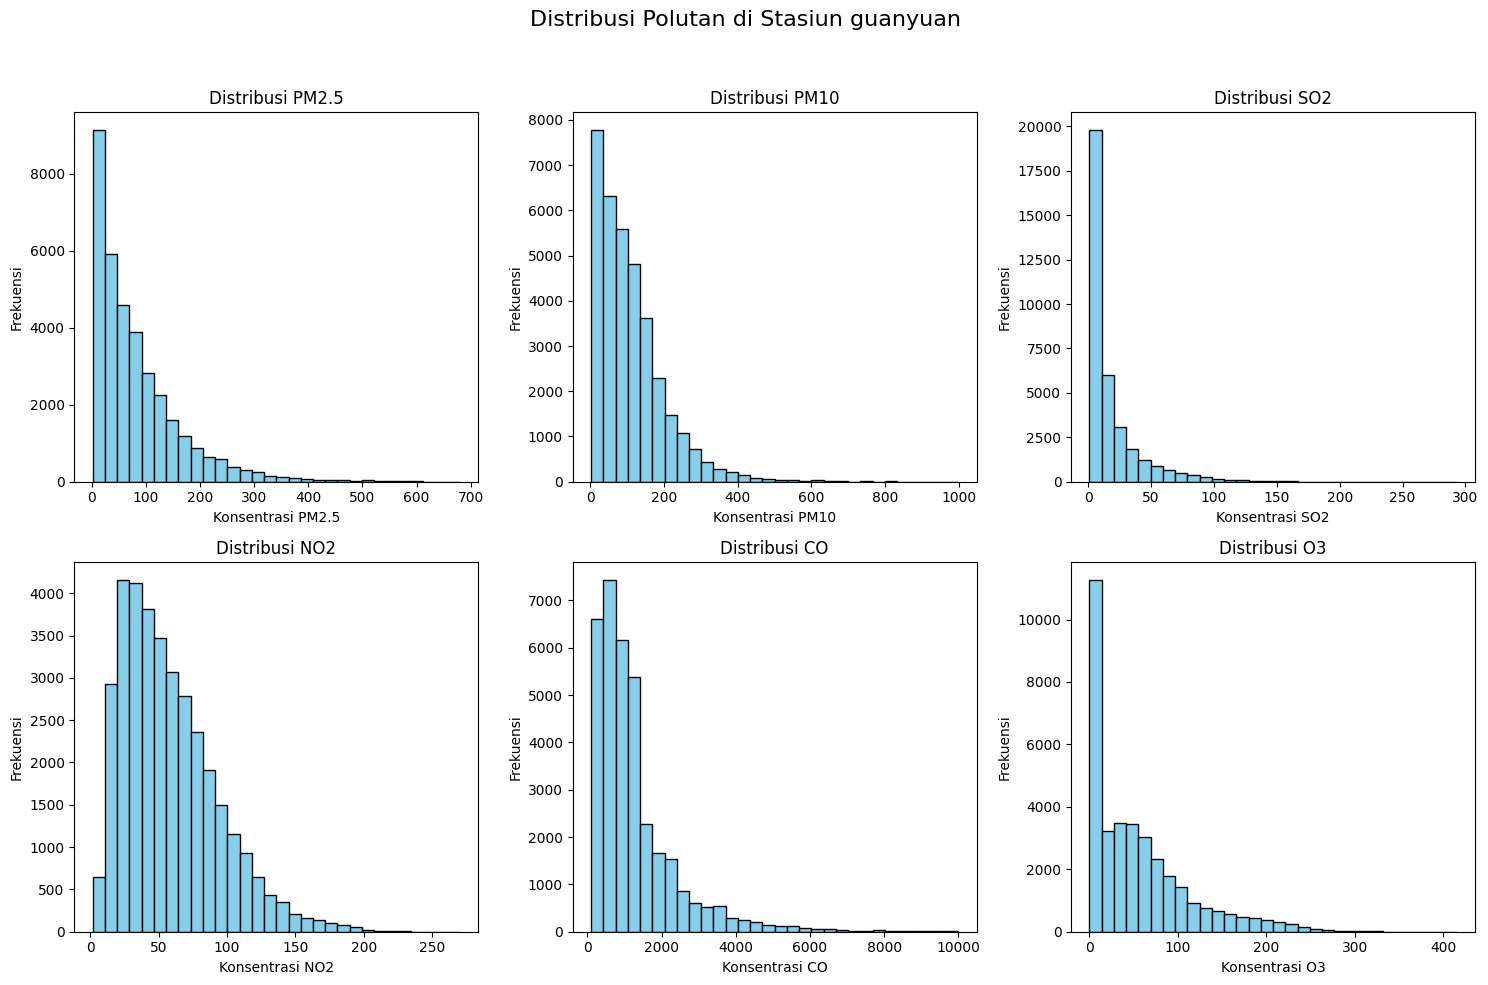

In [288]:
# Histogram untuk melihat sebaran polutan.
pollutants_guanyuan = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun guanyuan", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_guanyuan):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(guanyuan_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

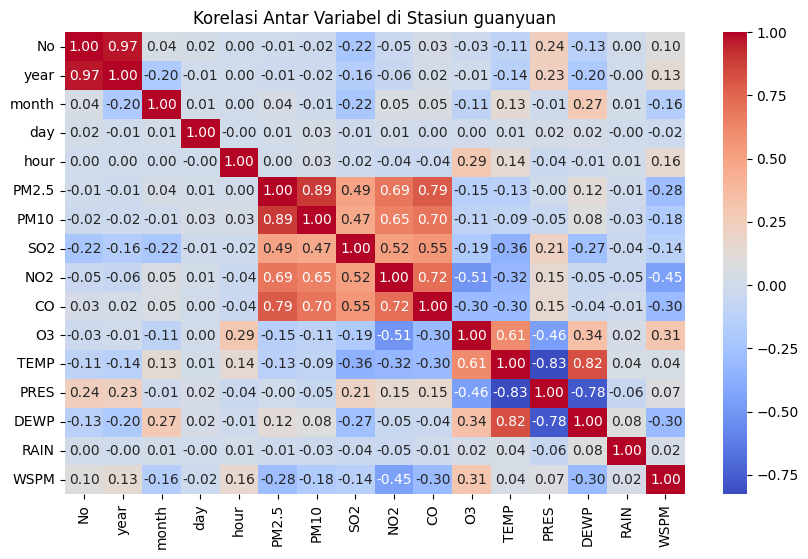

In [289]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_guanyuan = guanyuan_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(guanyuan_df[num_cols_guanyuan].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun guanyuan')
plt.show()

### Explore `gucheng_df`

In [290]:
print(gucheng_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10   SO2    NO2      CO    O3  \
9632    9633  2014      4    6     8   78.0  229.0  14.0  100.0  1200.0   7.0   
285      286  2013      3   12    21  145.0  110.0  22.0  102.0  1800.0  10.0   
12174  12175  2014      7   21     6   75.0   75.0   2.0   32.0   800.0  43.0   
29143  29144  2016      6   27     7   67.0  200.0  11.0   81.0   800.0  54.0   
2068    2069  2013      5   26     4  168.0  104.0  18.0   77.0   500.0  42.0   
22375  22376  2015      9   19     7   13.0   52.0   2.0   46.0   500.0  18.0   
34425  34426  2017      2    2     9   32.0   57.0  20.0   43.0   100.0  14.0   
27250  27251  2016      4    9    10   82.0  206.0  11.0  102.0  1000.0  24.0   
2332    2333  2013      6    6     4  201.0  212.0   3.0   62.0  2200.0   3.0   
32654  32655  2016     11   20    14   71.0   71.0   2.0   71.0  1900.0   3.0   

       TEMP    PRES  DEWP  RAIN   wd  WSPM  station  
9632   15.4  1013.1  -4.0   0.0    E   0.8  Gucheng  


In [291]:
print(gucheng_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

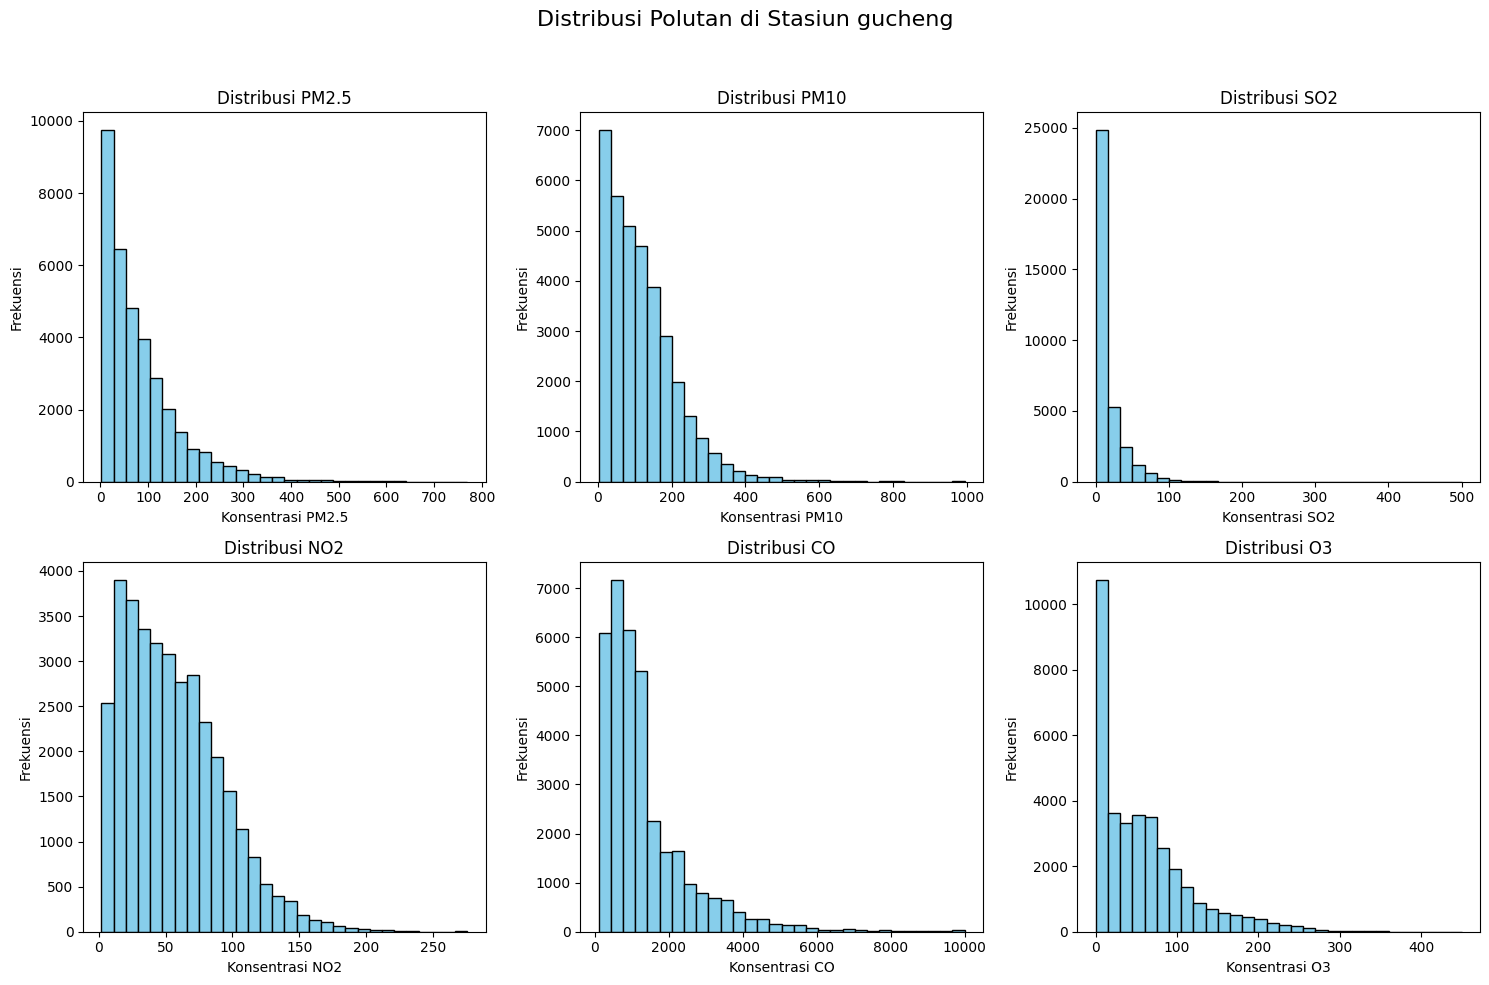

In [292]:
# Histogram untuk melihat sebaran polutan.
pollutants_gucheng = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun gucheng", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_gucheng):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(gucheng_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

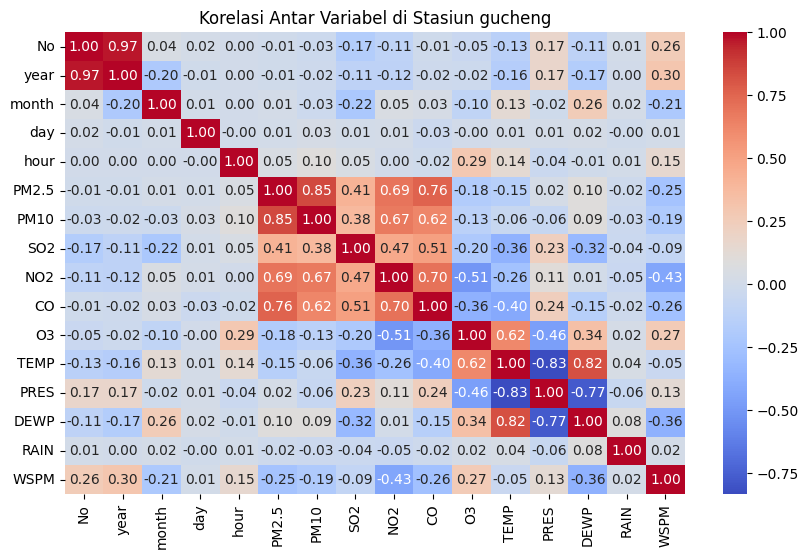

In [293]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_gucheng = gucheng_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(gucheng_df[num_cols_gucheng].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun gucheng')
plt.show()

### Explore `huairou_df`

In [294]:
print(huairou_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10   SO2   NO2      CO  \
23767  23768  2015     11   16     7   64.0   64.0   3.0  28.0  1300.0   
22398  22399  2015      9   20     6   19.0   37.0   2.0   9.0   400.0   
28156  28157  2016      5   17     4   14.0   24.0   2.0  12.0   300.0   
27093  27094  2016      4    2    21    7.0   42.0   2.0   6.0   300.0   
26009  26010  2016      2   17    17   53.0   53.0  11.0  22.0   600.0   
6607    6608  2013     12    1     7   23.0   37.0  26.0  59.0  1100.0   
31433  31434  2016      9   30    17   91.0   91.0  11.0  41.0   700.0   
27052  27053  2016      4    1     4   74.0  135.0  12.0  37.0   800.0   
17826  17827  2015      3   13    18    9.0   24.0   2.0  11.0   300.0   
14999  15000  2014     11   15    23  112.0  125.0  30.0  91.0  1600.0   

            O3  TEMP    PRES  DEWP  RAIN   wd  WSPM  station  
23767    2.000   5.9  1012.1   5.5   0.0   NW   1.0  Huairou  
22398   23.000  15.2  1006.1  13.4   0.0    S   0.8  Huairo

In [295]:
print(huairou_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

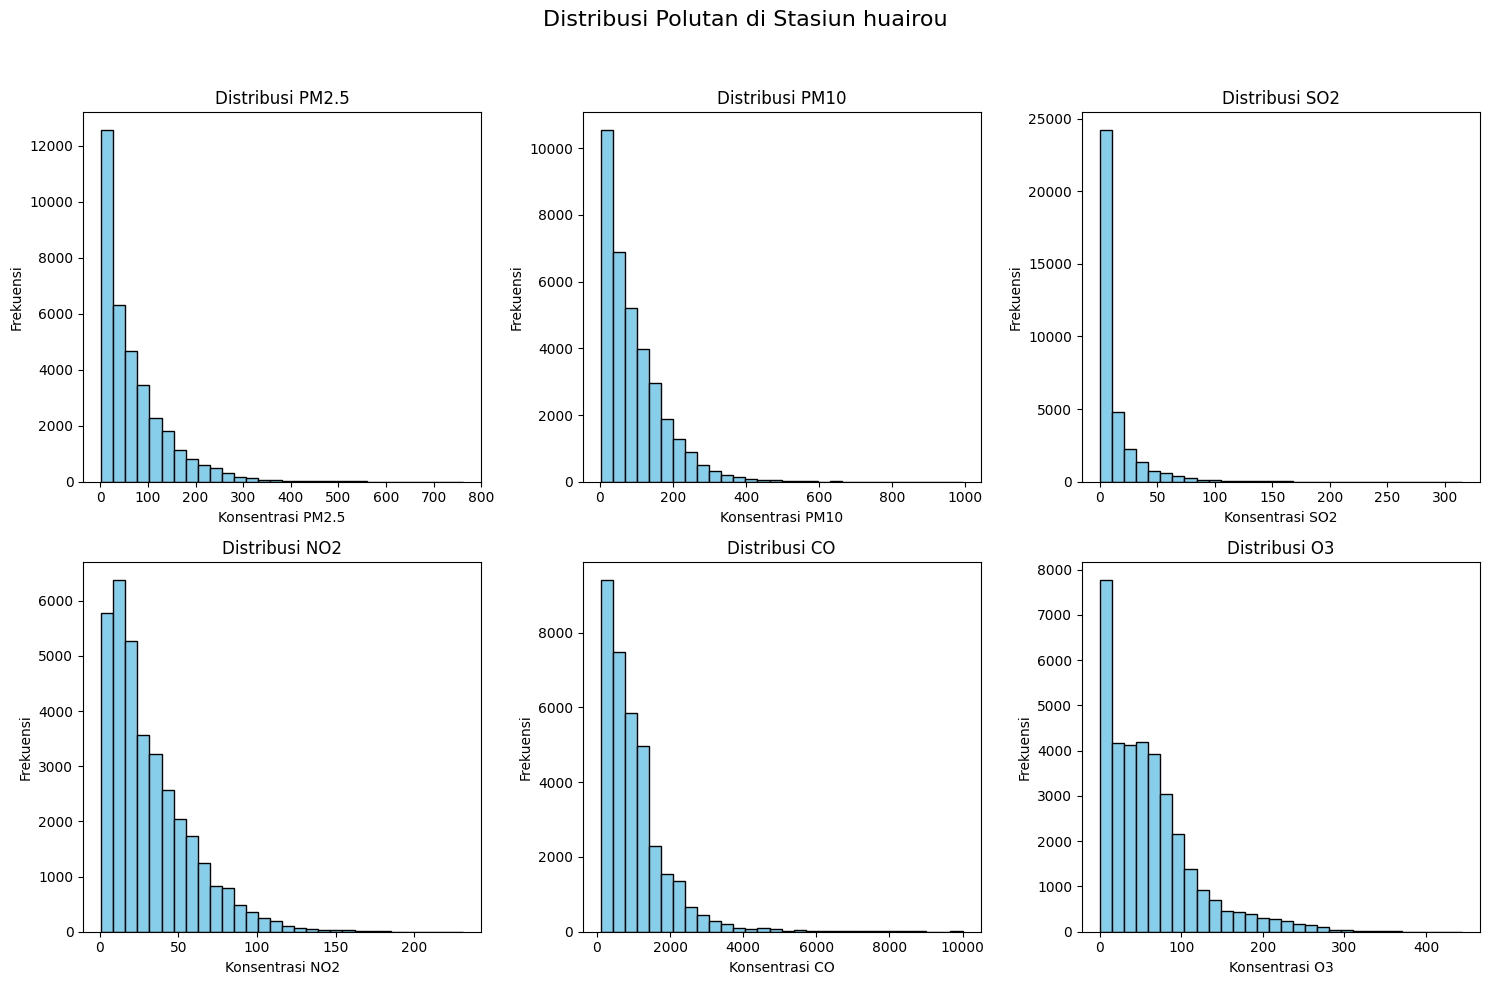

In [296]:
# Histogram untuk melihat sebaran polutan.
pollutants_huairou = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun huairou", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_huairou):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(huairou_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

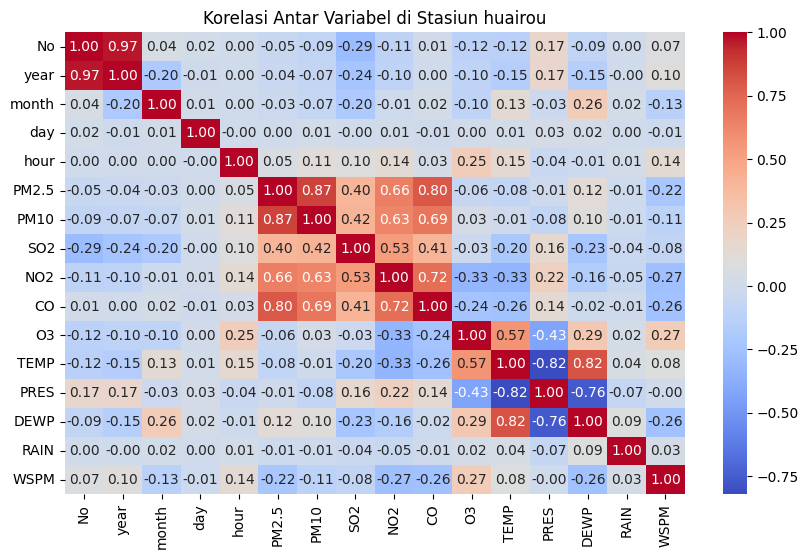

In [297]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_huairou = huairou_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(huairou_df[num_cols_huairou].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun huairou')
plt.show()

### Explore `nongzhanguan_df`

In [298]:
print(nongzhanguan_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10   SO2    NO2      CO  \
30803  30804  2016      9    4    11  117.0  117.0  17.0   37.0  1400.0   
23895  23896  2015     11   21    15   50.0   50.0   8.0   40.0  1600.0   
21031  21032  2015      7   25     7   81.0  100.0   2.0   72.0  1300.0   
10380  10381  2014      5    7    12   18.0   69.0   2.0   12.0   100.0   
19842  19843  2015      6    5    18   50.0   89.0   8.0   40.0   600.0   
5364    5365  2013     10   10    12   13.0   92.0   7.0   16.0   300.0   
16046  16047  2014     12   29    14   22.0   55.0  15.0   27.0   400.0   
22770  22771  2015     10    5    18  258.0  258.0  11.0   78.0  1700.0   
33760  33761  2017      1    5    16  201.0  216.0   3.0  108.0  3900.0   
24469  24470  2015     12   15    13    5.0    5.0   2.0   13.0   600.0   

          O3  TEMP    PRES  DEWP  RAIN   wd  WSPM       station  
30803  125.0  28.4  1006.3  18.5   0.0  ESE   1.5  Nongzhanguan  
23895    4.0   0.0  1027.5  -0.6   0.0    

In [299]:
print(nongzhanguan_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

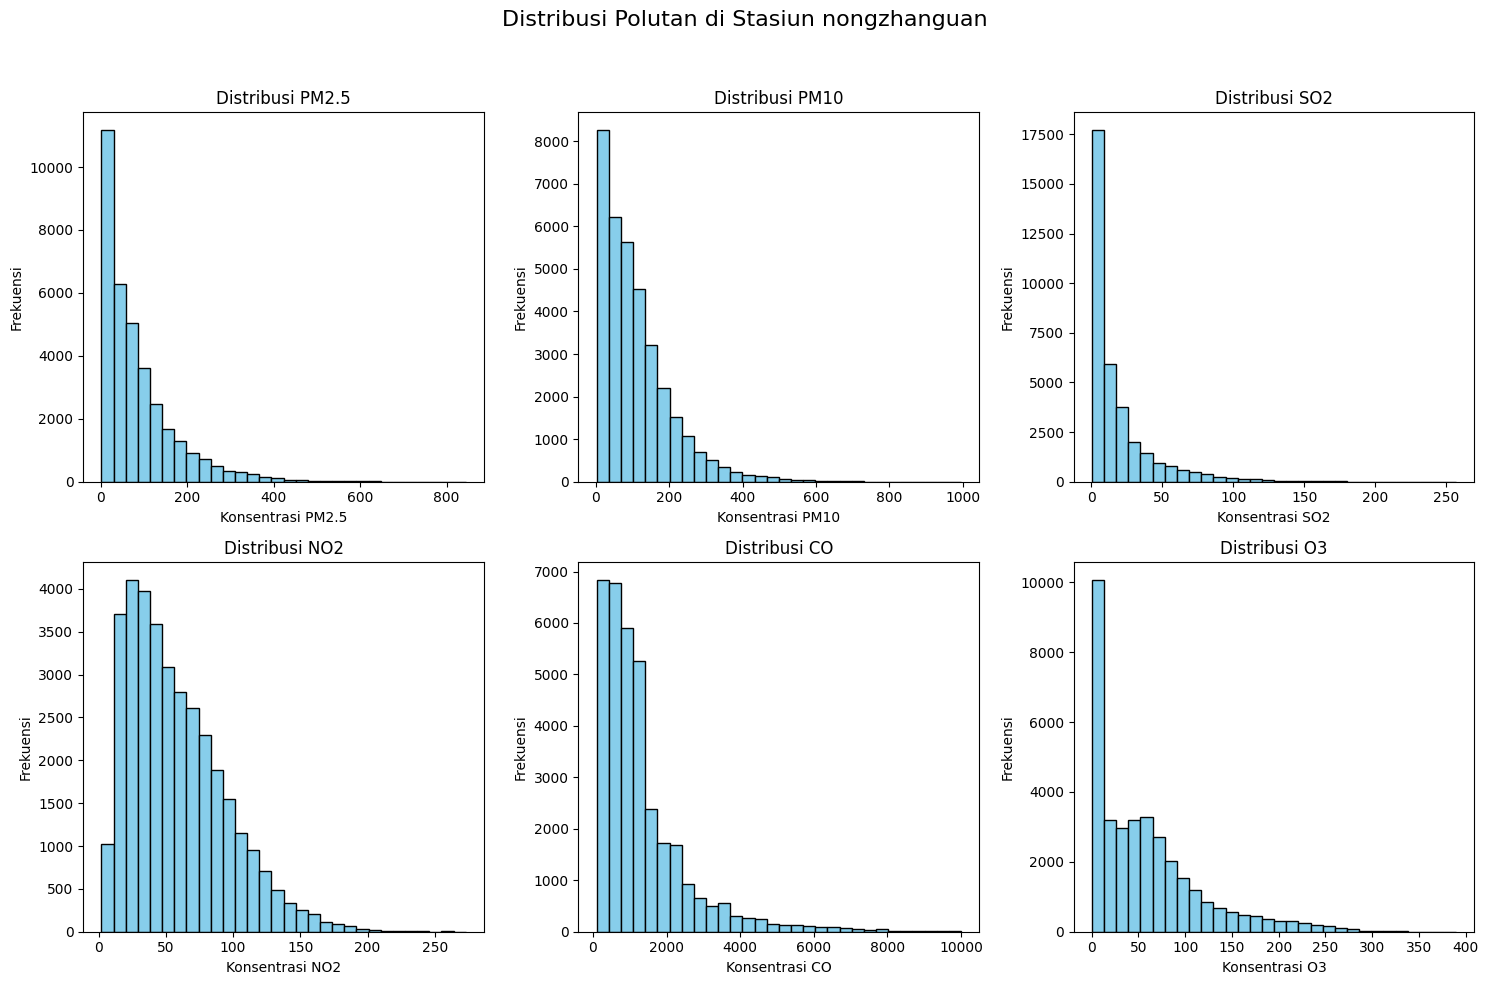

In [300]:
# Histogram untuk melihat sebaran polutan.
pollutants_nongzhanguan = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun nongzhanguan", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_nongzhanguan):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(nongzhanguan_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

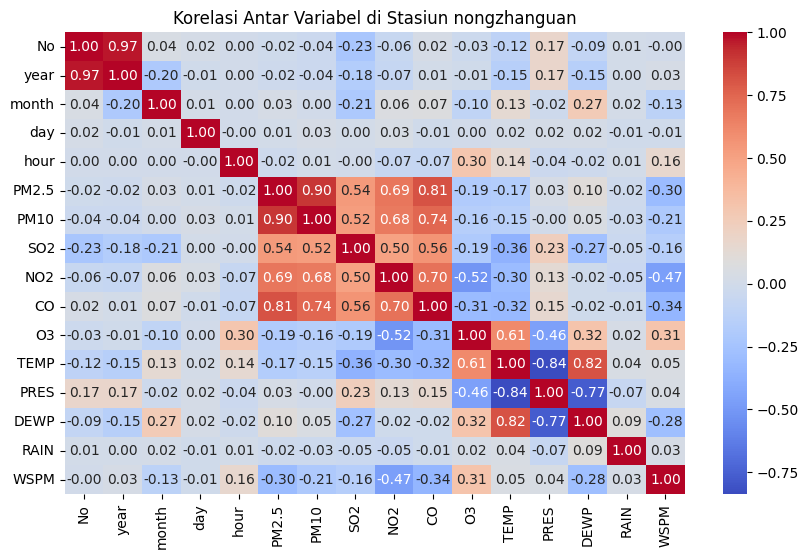

In [301]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_nongzhanguan = nongzhanguan_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(nongzhanguan_df[num_cols_nongzhanguan].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun nongzhanguan')
plt.show()

### Explore `shunyi_df`

In [302]:
print(shunyi_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10   SO2         NO2      CO  \
17789  17790  2015      3   12     5   81.0   92.0  13.0   70.000000  1200.0   
24127  24128  2015     12    1     7  399.0  399.0  31.0  114.000000  8100.0   
29296  29297  2016      7    3    16   43.0   43.0   4.0   18.000000   600.0   
27178  27179  2016      4    6    10   90.0  139.0  51.0   81.000000  2500.0   
24403  24404  2015     12   12    19  145.0  150.0  12.0  109.000000  2800.0   
19280  19281  2015      5   13     8   29.0   69.0   5.0   40.000000   400.0   
919      920  2013      4    8     7   19.0   62.0   3.0   19.000000   500.0   
10641  10642  2014      5   18     9   62.0  111.0  28.0  103.629717   900.0   
16908  16909  2015      2    3    12  195.0  195.0  51.0   77.000000  2200.0   
34811  34812  2017      2   18    11   97.0  133.0  32.0   63.000000  1000.0   

          O3  TEMP    PRES  DEWP  RAIN   wd  WSPM station  
17789    2.0  -0.4  1014.9 -11.8   0.0  NNE   1.3  Shunyi  

In [303]:
print(shunyi_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

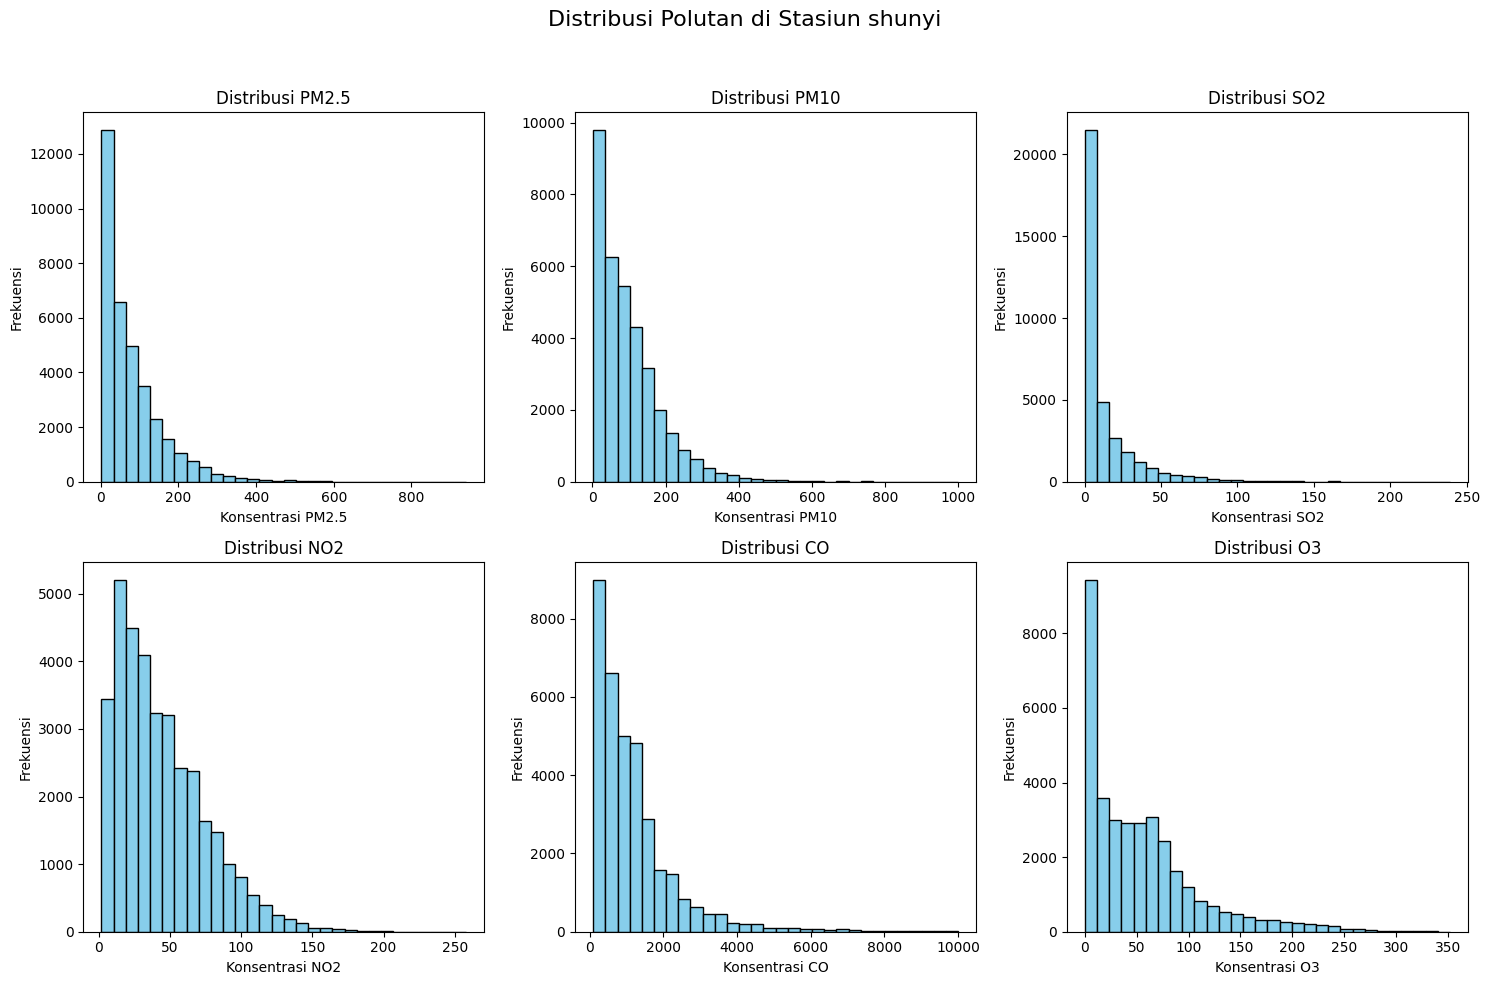

In [304]:
# Histogram untuk melihat sebaran polutan.
pollutants_shunyi = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun shunyi", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_shunyi):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(shunyi_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

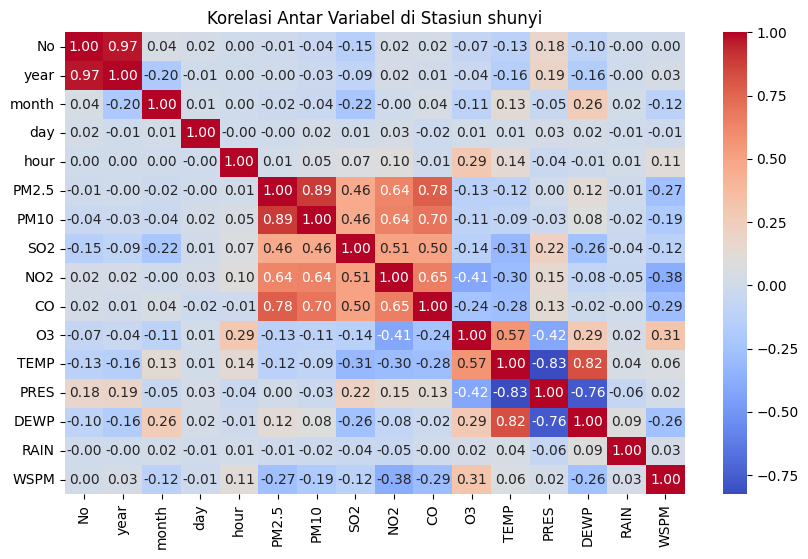

In [305]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_shunyi = shunyi_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(shunyi_df[num_cols_shunyi].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun shunyi')
plt.show()

### Explore `tiantan_df`

In [306]:
print(tiantan_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10        SO2        NO2  \
15196  15197  2014     11   24     4  153.0  158.0   3.000000  62.000000   
19821  19822  2015      6    4    21   71.0   71.0   5.000000  35.000000   
29725  29726  2016      7   21    13   39.0   39.0   2.000000  38.000000   
16534  16535  2015      1   18    22   10.0   54.0   6.000000  20.000000   
2877    2878  2013      6   28    21  438.0  387.0  33.000000  78.000000   
25846  25847  2016      2   10    22  138.0  141.0  37.000000  96.000000   
10003  10004  2014      4   21    19   21.0   69.0   5.000000  32.000000   
8555    8556  2014      2   20    11  163.0  163.0  60.531915  78.510638   
16890  16891  2015      2    2    18  142.0  142.0  66.000000  89.000000   
24454  24455  2015     12   14    22   11.0   11.0   9.000000  33.000000   

           CO          O3  TEMP    PRES  DEWP  RAIN   wd  WSPM  station  
15196  3200.0    5.000000  -1.0  1021.0  -1.3   0.0  ENE   2.0  Tiantan  
19821  9000.0  

In [307]:
print(tiantan_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

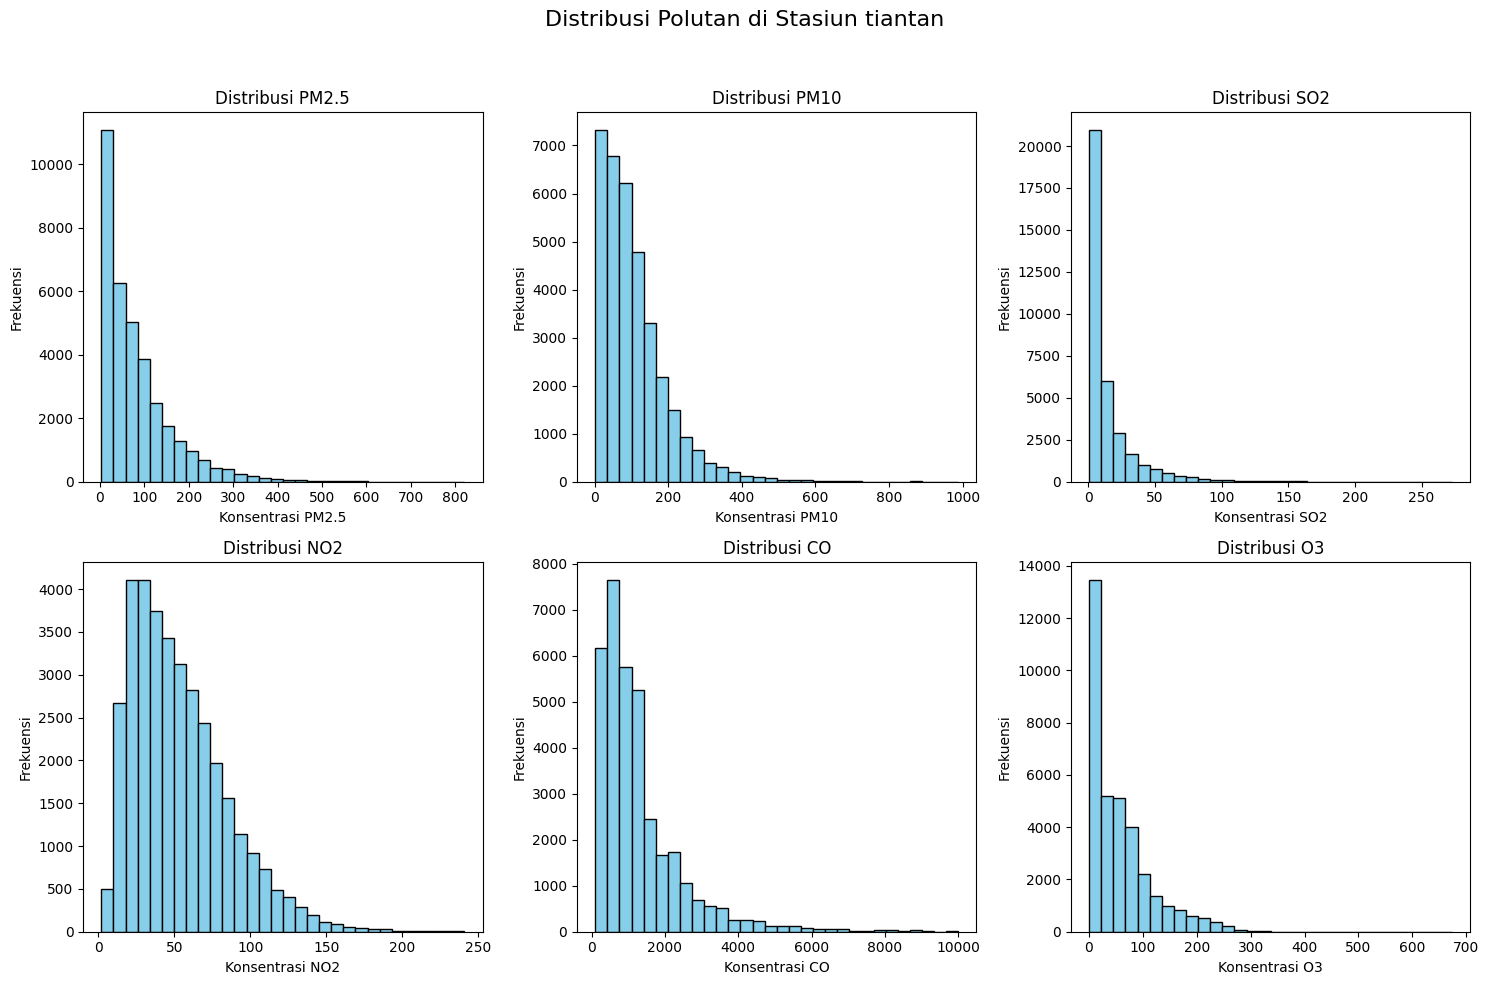

In [308]:
# Histogram untuk melihat sebaran polutan.
pollutants_tiantan = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun tiantan", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_tiantan):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(tiantan_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

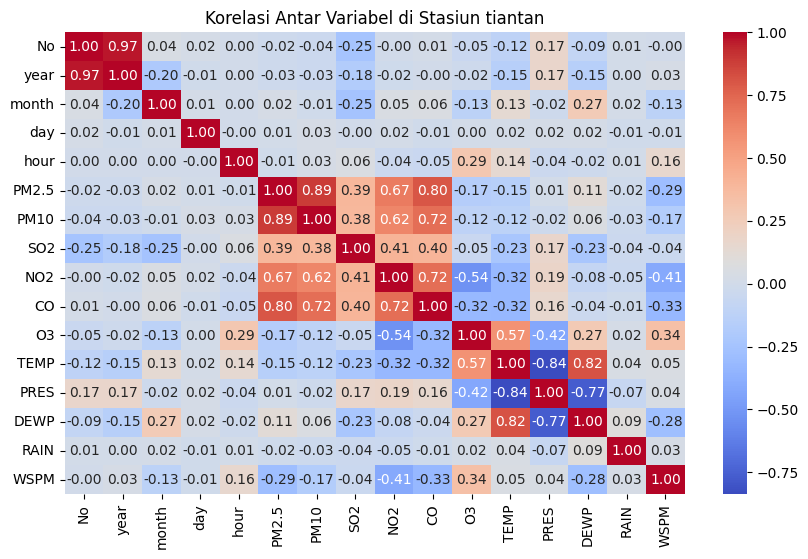

In [309]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_tiantan = tiantan_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(tiantan_df[num_cols_tiantan].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun tiantan')
plt.show()

### Explore `wanliu_df`

In [310]:
print(wanliu_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10       SO2      NO2      CO  \
9668    9669  2014      4    7    20  112.0  186.0   20.0000   99.000   900.0   
21999  22000  2015      9    3    15   17.0   20.0    2.0000    2.000   400.0   
28508  28509  2016      5   31    20   15.0   76.0    5.0000   42.000   500.0   
783      784  2013      4    2    15  152.0  170.0   54.0000   83.000  2000.0   
1221    1222  2013      4   20    21   71.0  128.0   18.0000   58.000   800.0   
2707    2708  2013      6   21    19   57.0   60.0   13.7088   69.802  1300.0   
9091    9092  2014      3   14    19   31.0  103.0   19.0000   69.000   600.0   
28305  28306  2016      5   23     9   83.0   83.0   14.0000   79.000  1400.0   
29043  29044  2016      6   23     3   96.0  154.0    2.0000   56.000  1000.0   
8449    8450  2014      2   16     1  468.0  433.0  106.0000  164.000  6600.0   

          O3  TEMP    PRES  DEWP  RAIN   wd  WSPM station  
9668    82.0  18.8  1006.8   5.9   0.0   SW   1.

In [311]:
print(wanliu_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

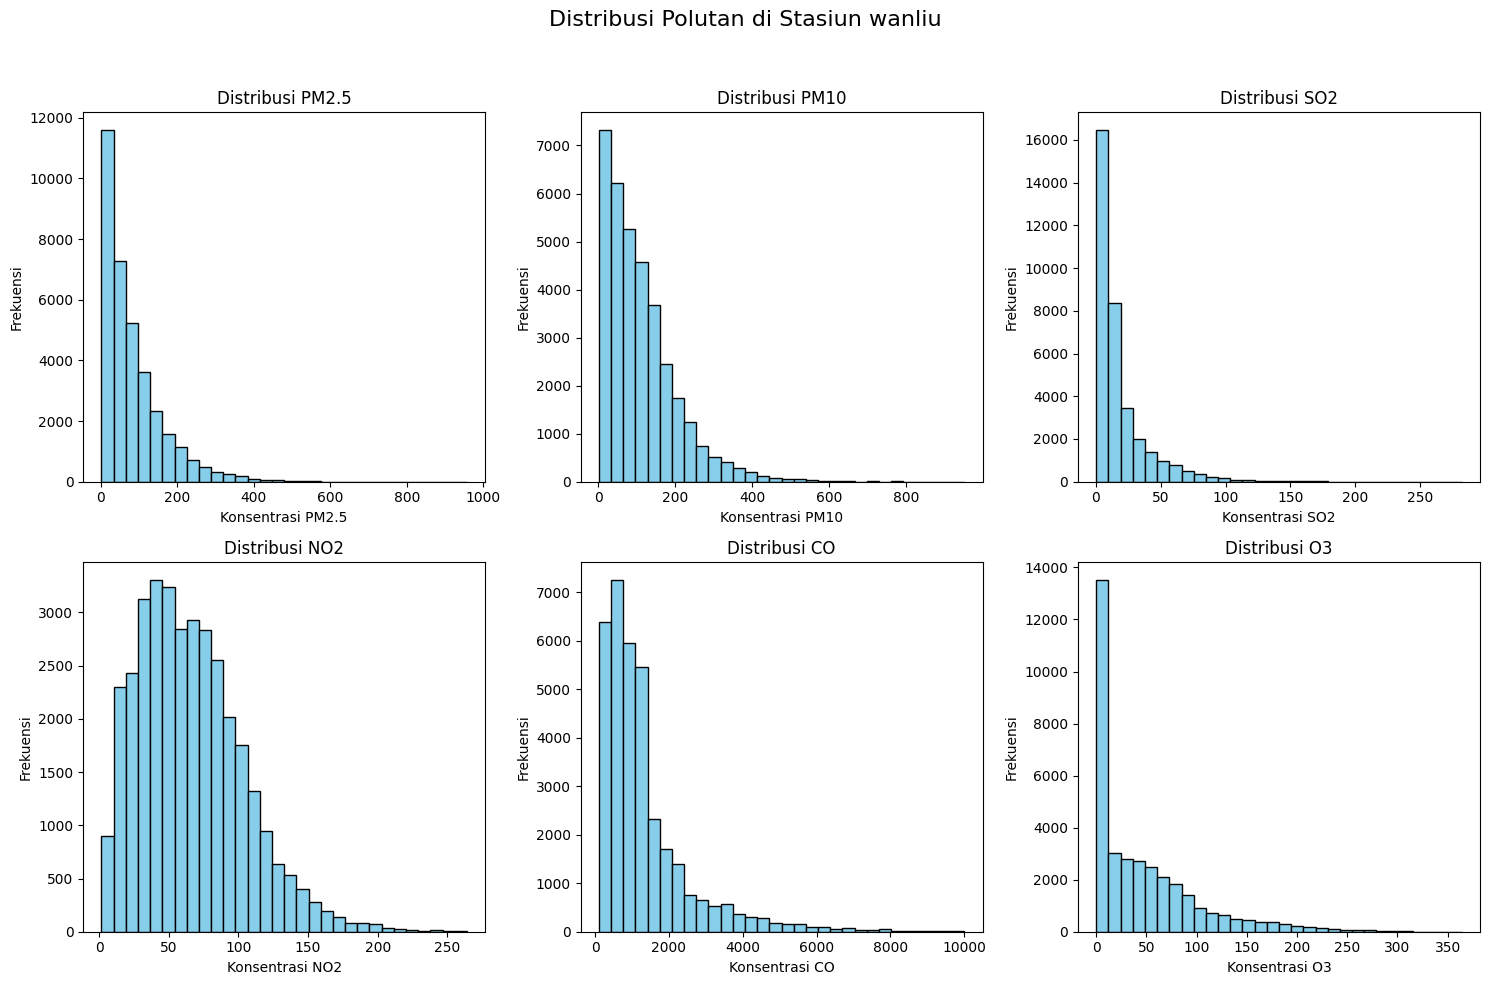

In [312]:
# Histogram untuk melihat sebaran polutan.
pollutants_wanliu = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun wanliu", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_wanliu):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(wanliu_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

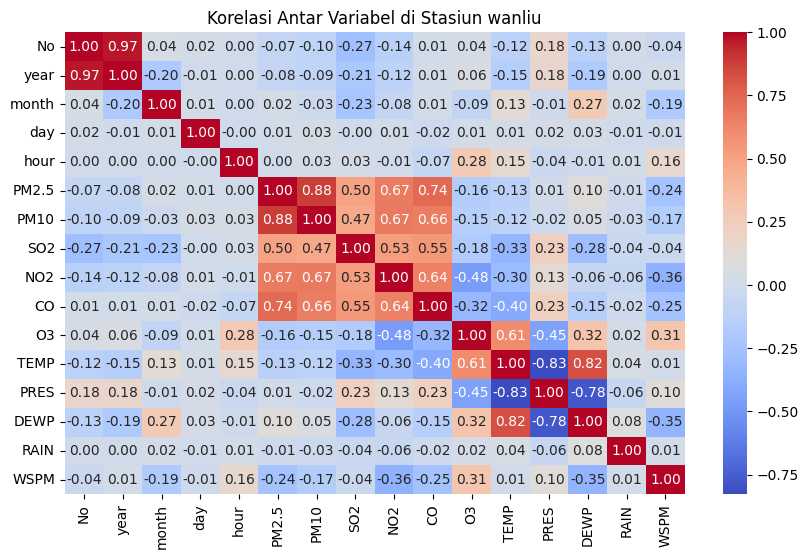

In [313]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_wanliu = wanliu_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(wanliu_df[num_cols_wanliu].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun wanliu')
plt.show()

### Explore `wanshouxigong_df`

In [314]:
print(wanshouxigong_df.sample(10))  # Tampilkan 10 sampel acak

          No  year  month  day  hour  PM2.5   PM10   SO2    NO2      CO  \
34571  34572  2017      2    8    11   10.0   35.0   5.0    9.0   300.0   
17743  17744  2015      3   10     7   20.0   27.0  16.0   82.0  1900.0   
11085  11086  2014      6    5    21   61.0  135.0   5.0   58.0   900.0   
11998  11999  2014      7   13    22   30.0   73.0   2.0   88.0  1000.0   
22847  22848  2015     10    8    23   33.0   33.0   4.0   69.0   500.0   
1497    1498  2013      5    2     9   83.0  120.0  49.0   65.0  1100.0   
13445  13446  2014      9   12     5   76.0   76.0   2.0   39.0   900.0   
21401  21402  2015      8    9    17   47.0   47.0   2.0   20.0   700.0   
14295  14296  2014     10   17    15   96.0  188.0  19.0  128.0  1100.0   
13780  13781  2014      9   26     4  101.0  101.0   3.0   51.0  1100.0   

          O3  TEMP    PRES  DEWP  RAIN   wd  WSPM        station  
34571   68.0   1.9  1027.8 -18.2   0.0  NNW   3.9  Wanshouxigong  
17743    2.0  -7.2  1030.7 -19.1   0.0  

In [315]:
print(wanshouxigong_df.describe(include='all'))  # Statistik untuk semua tipe data

                  No          year         month           day          hour  \
count   35064.000000  35064.000000  35064.000000  35064.000000  35064.000000   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    17532.500000   2014.662560      6.522930     15.729637     11.500000   
std     10122.249256      1.177213      3.448752      8.800218      6.922285   
min         1.000000   2013.000000      1.000000      1.000000      0.000000   
25%      8766.750000   2014.000000      4.000000      8.000000      5.750000   
50%     17532.500000   2015.000000      7.000000     16.000000     11.500000   
75%     26298.250000   2016.000000     10.000000     23.000000     17.250000   
max     35064.000000   2017.000000     12.000000     31.000000     23.000000   

               PM2.5          PM10     

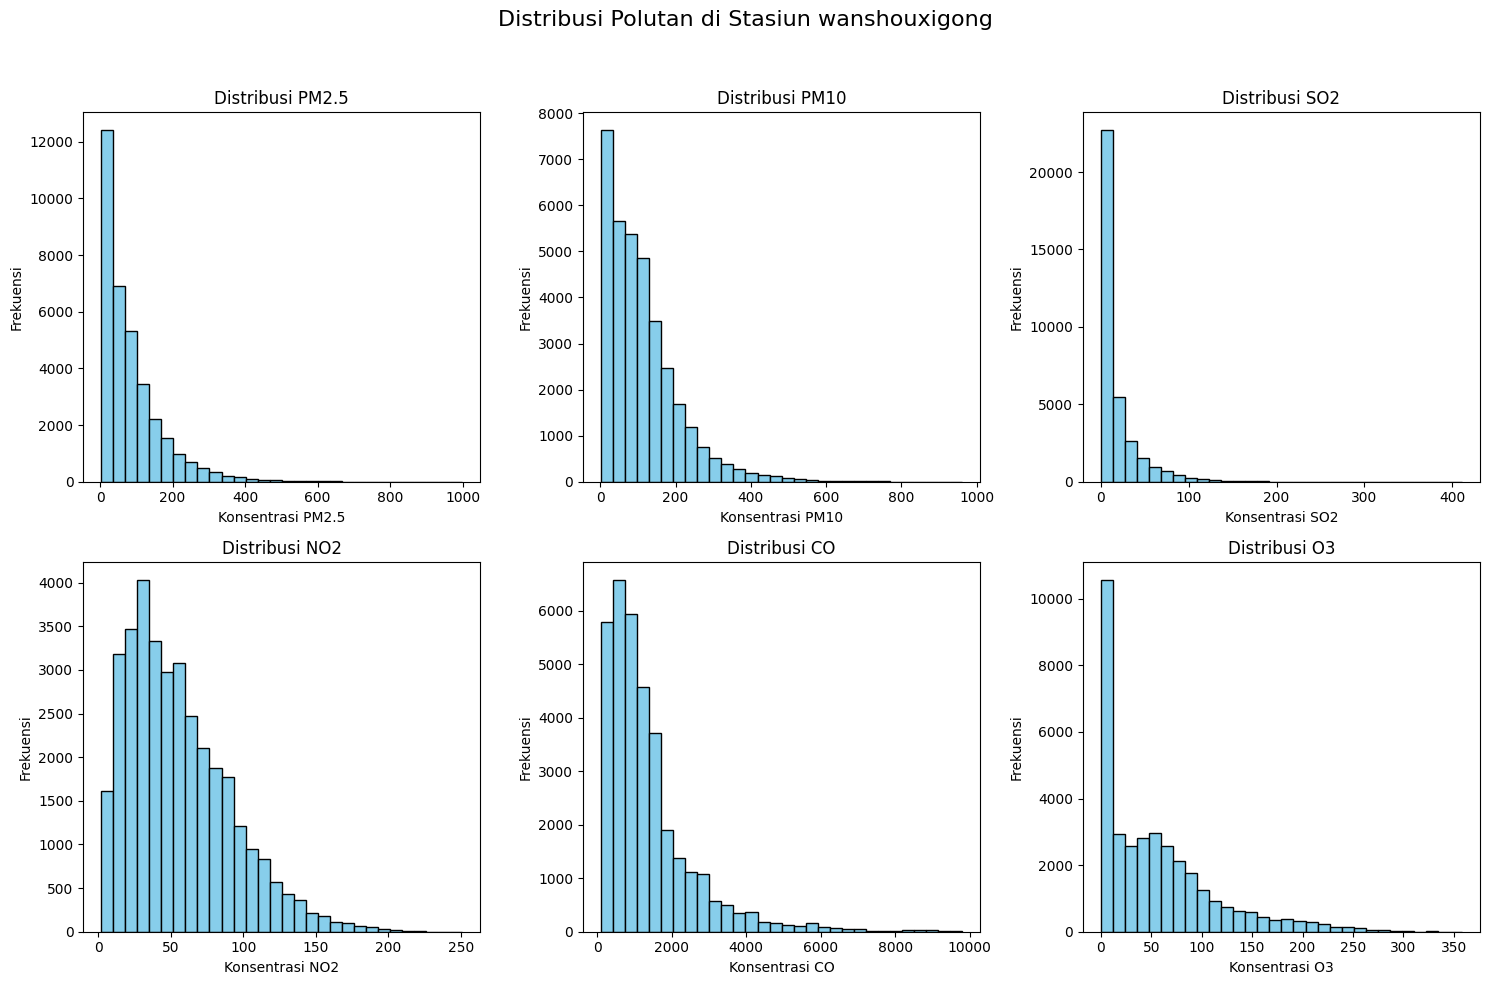

In [316]:
# Histogram untuk melihat sebaran polutan.
pollutants_wanshouxigong = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Buat histogram
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
fig.suptitle("Distribusi Polutan di Stasiun wanshouxigong", fontsize=16)

# Looping untuk setiap polutan
for i, col in enumerate(pollutants_wanshouxigong):
    ax = axes[i // 3, i % 3]  # Atur posisi subplot
    ax.hist(wanshouxigong_df[col], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel(f'Konsentrasi {col}')  # X-axis menunjukkan konsentrasi polutan
    ax.set_ylabel('Frekuensi')  # Y-axis menunjukkan jumlah kejadian

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

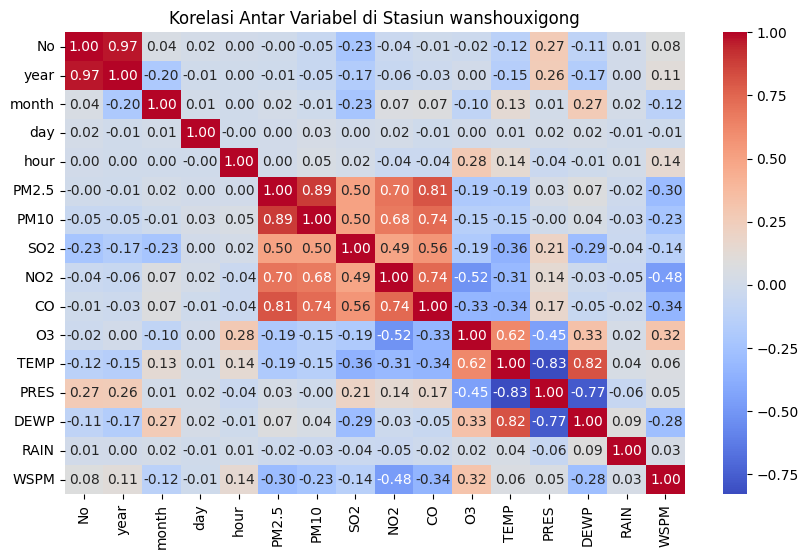

In [317]:
# Pilih hanya kolom numerik (exclude "wd" dan "station" karena bertipe string)
num_cols_wanshouxigong = wanshouxigong_df.select_dtypes(include=['float64', 'int64']).columns

# Plot heatmap korelasi
plt.figure(figsize=(10,6))
sns.heatmap(wanshouxigong_df[num_cols_wanshouxigong].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel di Stasiun wanshouxigong')
plt.show()

### Explore all data

Menggabungkan semua tabel dan membuat file `.csv` baru yang berisi semua tabel

In [318]:
# List nama semua stasiun
stations = ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 
            'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']

# Gabungkan semua dataframe
all_data = pd.concat([eval(f"{station.lower()}_df") for station in stations], ignore_index=True)

# Hapus kolom 'No'
all_data.drop(columns=['No'], inplace=True)

# Urutkan berdasarkan tahun, bulan, hari, dan jam
all_data = all_data.sort_values(by=['year', 'month', 'day', 'hour']).reset_index(drop=True)

# Simpan ke file CSV baru
all_data.to_csv("merged_air_quality.csv", index=False)

In [319]:
# Cek struktur data
print(all_data.info())
print(all_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 17 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   year     420768 non-null  int64  
 1   month    420768 non-null  int64  
 2   day      420768 non-null  int64  
 3   hour     420768 non-null  int64  
 4   PM2.5    420768 non-null  float64
 5   PM10     420768 non-null  float64
 6   SO2      420768 non-null  float64
 7   NO2      420748 non-null  float64
 8   CO       420768 non-null  float64
 9   O3       420768 non-null  float64
 10  TEMP     420768 non-null  float64
 11  PRES     420768 non-null  float64
 12  DEWP     420768 non-null  float64
 13  RAIN     420768 non-null  float64
 14  wd       420768 non-null  object 
 15  WSPM     420768 non-null  float64
 16  station  420768 non-null  object 
dtypes: float64(11), int64(4), object(2)
memory usage: 54.6+ MB
None
   year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  TEMP    PRES  

In [320]:
print("Jumlah baris setelah merge:", all_data.shape[0])
print("Jumlah kolom setelah merge:", all_data.shape[1])

Jumlah baris setelah merge: 420768
Jumlah kolom setelah merge: 17


In [321]:
print(all_data.sample(5))

        year  month  day  hour  PM2.5   PM10   SO2    NO2      CO     O3  \
139527  2014      6   28    11   13.0   13.0   2.0   20.0   300.0  105.0   
331644  2016      4   25    13  154.0  154.0  39.0   25.0  1300.0  160.0   
295855  2015     12   23     6  334.0  334.0  19.0  149.0  6800.0   12.0   
196073  2015      1   10    19  246.0  294.0  81.0  137.0  3300.0   17.0   
14192   2013      4   19     6   28.0   55.0  24.0   33.0   800.0   47.0   

        TEMP    PRES  DEWP  RAIN   wd  WSPM       station  
139527  33.9  1001.5  12.8   0.0    N   4.2        Dongsi  
331644  26.0  1007.9  10.6   0.0  SSW   3.5  Aotizhongxin  
295855  -3.7  1021.8  -3.7   0.0  ENE   0.9  Nongzhanguan  
196073   3.0  1014.0 -13.3   0.0   NW   1.0       Gucheng  
14192    7.0  1022.8  -6.4   0.0    S   1.9        Shunyi  


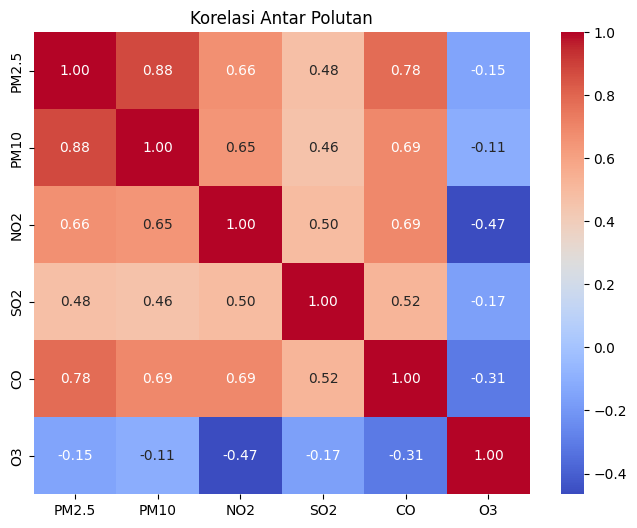

In [322]:
plt.figure(figsize=(8,6))
sns.heatmap(all_data[["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Antar Polutan")
plt.show()

### **Insight:**
- EDA pada masing-masing tabel membantu memahami distribusi data sebelum melakukan merge.
- Mengetahui sebaran polutan dan korelasi antar variabel (merah = korelasi positig; biru = korleasi negatif).

## Visualization & Explanatory Analysis

###  Bagaimana tren polusi udara dari waktu ke waktu di setiap stasiun?

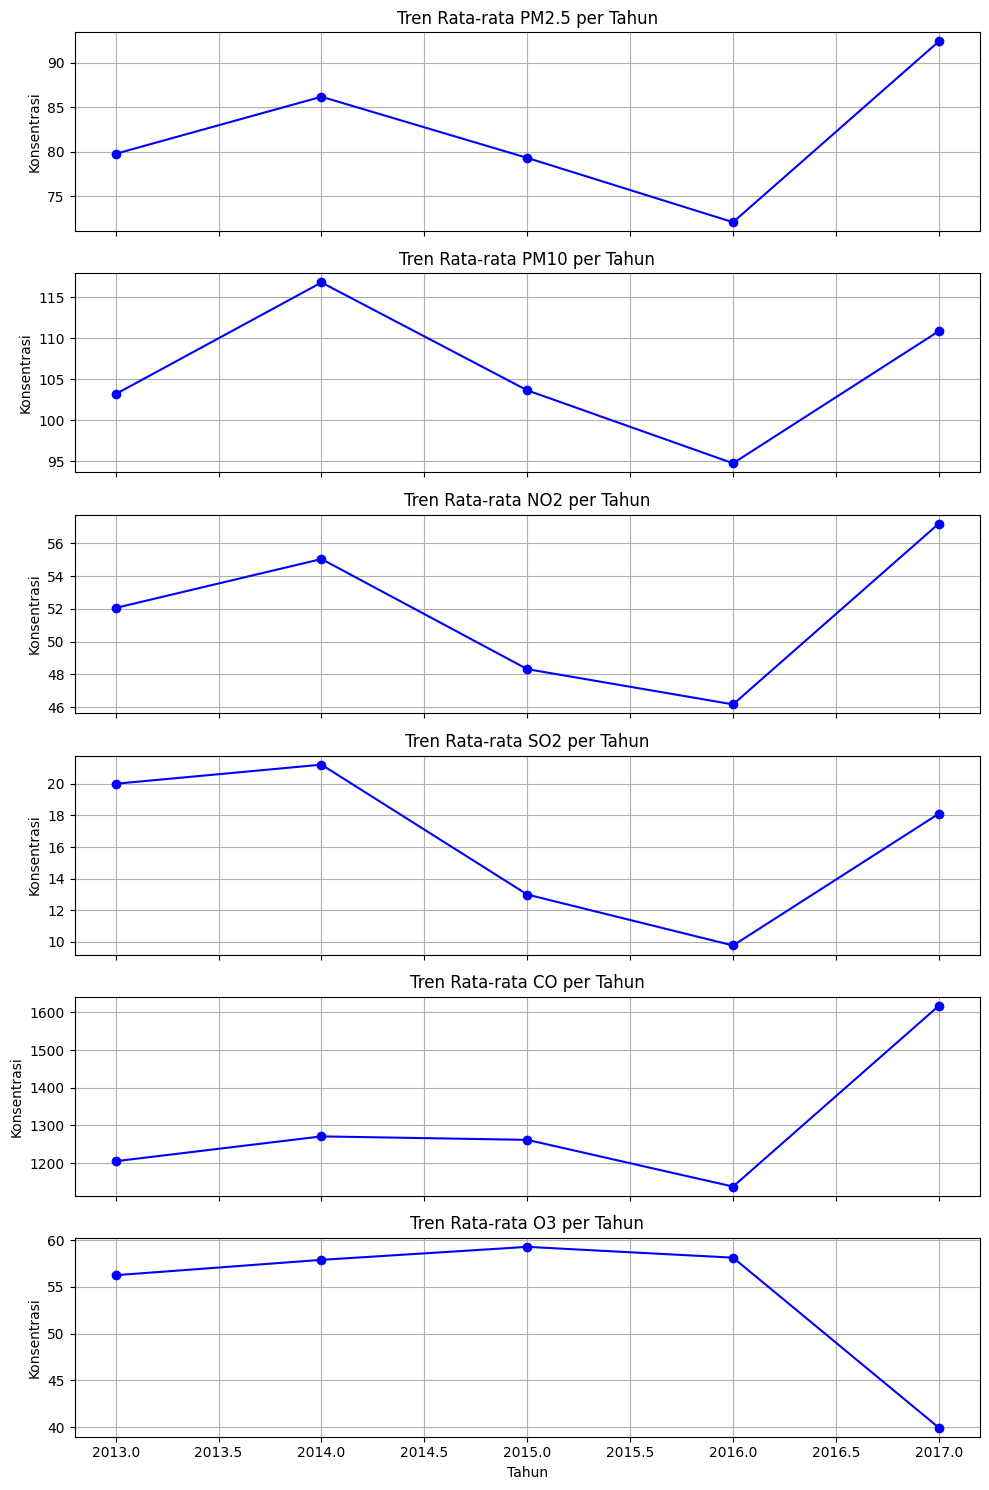

In [323]:
pollutants = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]
fig, axes = plt.subplots(len(pollutants), 1, figsize=(10, 15), sharex=True)

for i, pollutant in enumerate(pollutants):
    axes[i].plot(all_data.groupby('year')[pollutant].mean(), marker='o', linestyle='-', color='b')
    axes[i].set_title(f'Tren Rata-rata {pollutant} per Tahun')
    axes[i].set_ylabel('Konsentrasi')
    axes[i].grid(True)

axes[-1].set_xlabel('Tahun')
plt.tight_layout()
plt.show()

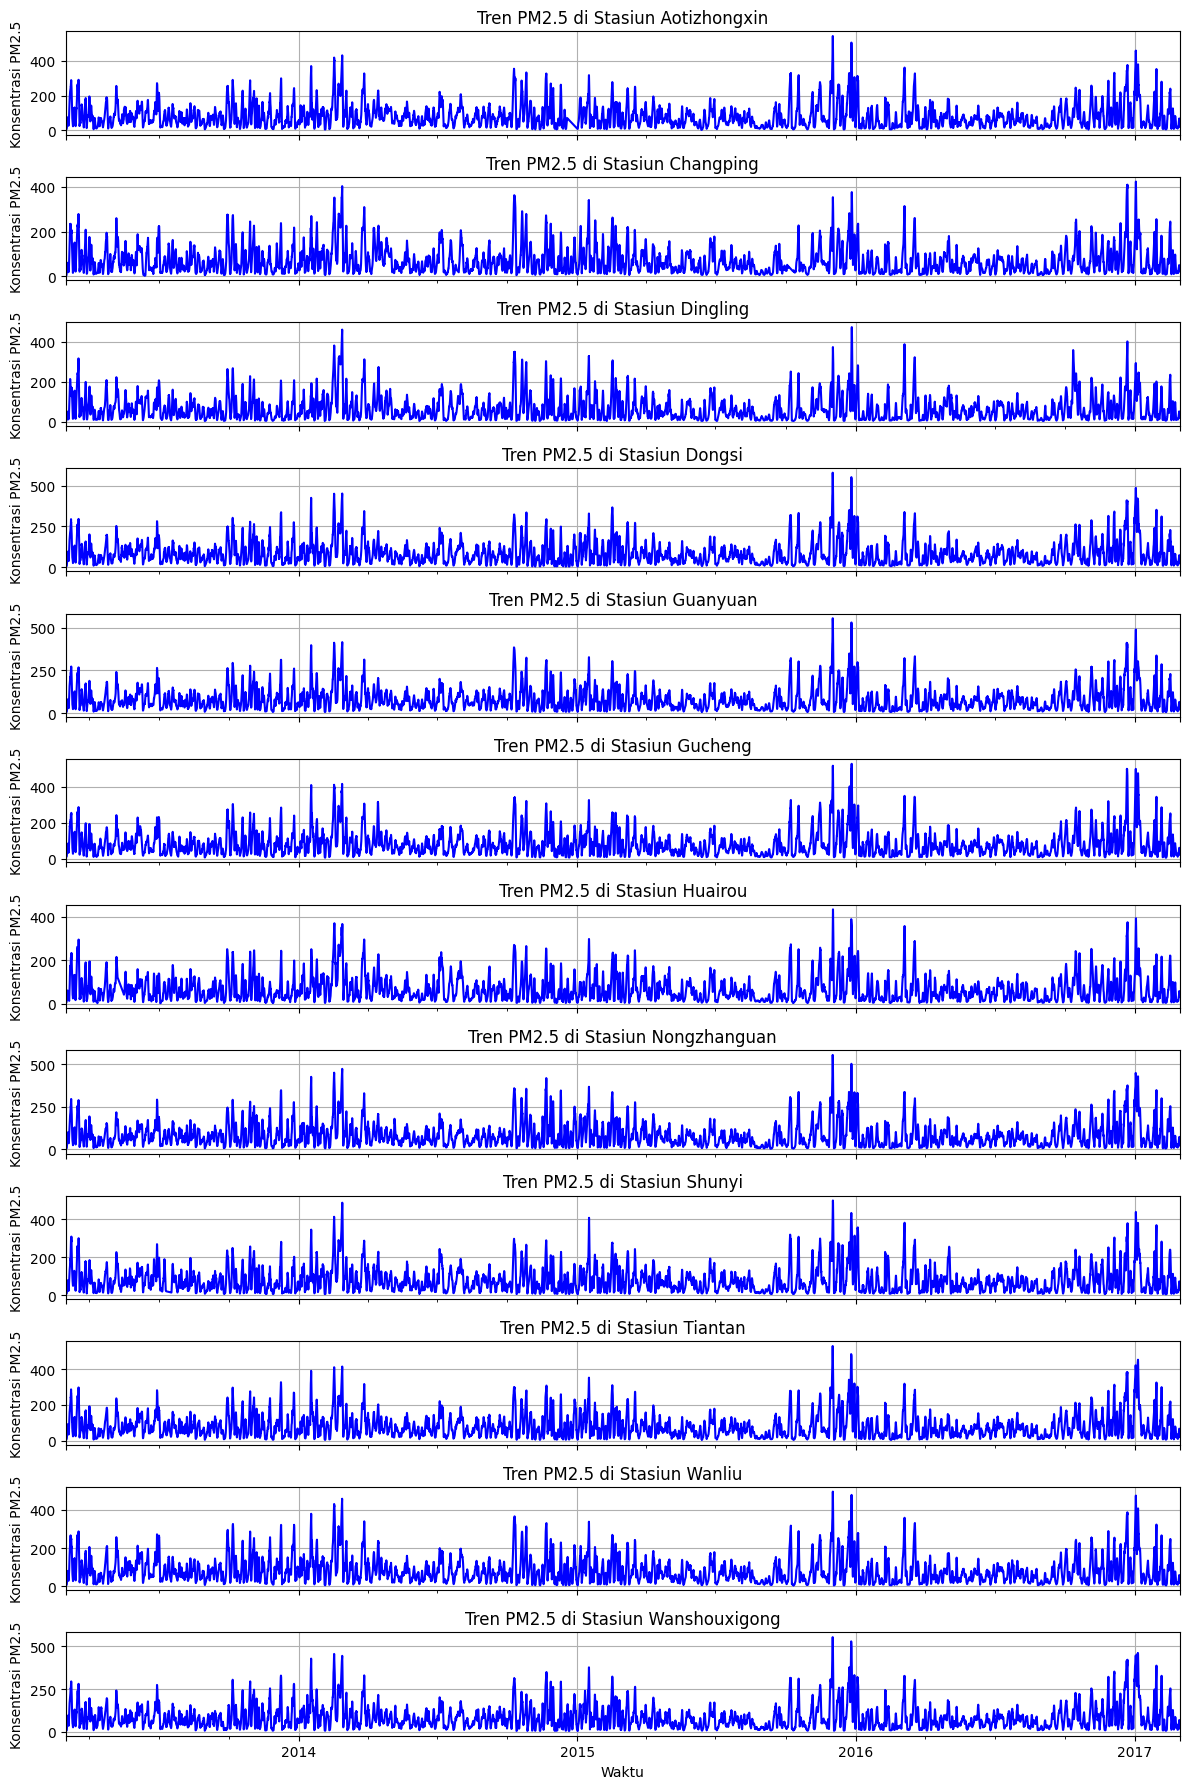

In [324]:
stations = all_data['station'].unique()
fig, axes = plt.subplots(len(stations), 1, figsize=(12, 18), sharex=True)

for i, station in enumerate(stations):
    subset = all_data[all_data['station'] == station]
    subset = subset.set_index(pd.to_datetime(subset[['year', 'month', 'day', 'hour']]))  # Jadikan waktu sebagai index
    subset['PM2.5'].rolling(window=30).mean().plot(ax=axes[i], color='b', linewidth=1.5)  # Rolling mean untuk memperhalus

    axes[i].set_title(f'Tren PM2.5 di Stasiun {station}')
    axes[i].set_ylabel('Konsentrasi PM2.5')
    axes[i].grid(True)

axes[-1].set_xlabel('Waktu')
plt.tight_layout()
plt.show()

### Stasiun mana yang memiliki rata-rata tingkat polusi tertinggi dan terendah?

C:\Users\heris\AppData\Local\Temp\ipykernel_2084\3424618547.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
C:\Users\heris\AppData\Local\Temp\ipykernel_2084\3424618547.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
C:\Users\heris\AppData\Local\Temp\ipykernel_2084\3424618547.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)


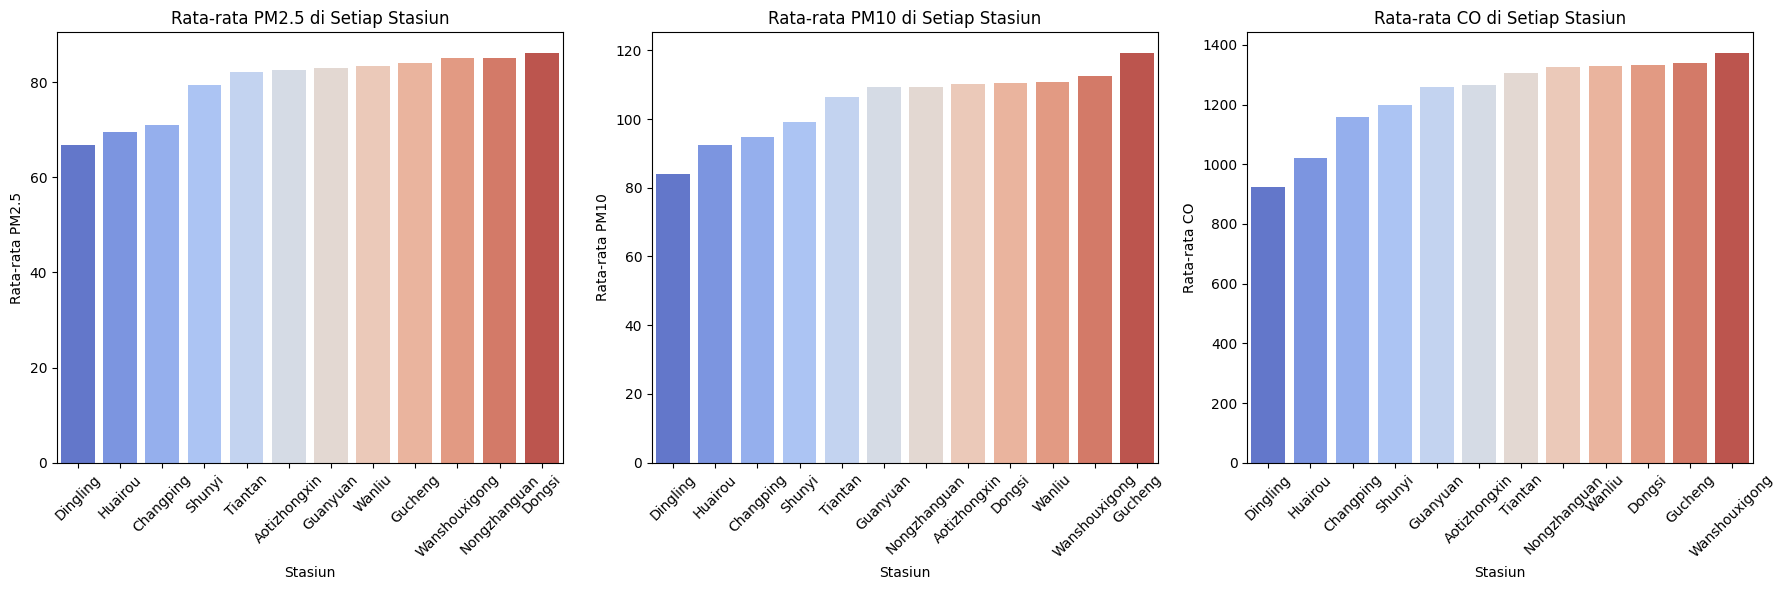

In [325]:
pollutants_pertanyaan2 = ["PM2.5", "PM10", "CO"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Tidak pakai sharey agar skala Y bebas

for i, pollutant in enumerate(pollutants_pertanyaan2):
    station_avg = all_data.groupby('station')[pollutant].mean().sort_values()
    sns.barplot(x=station_avg.index, y=station_avg.values, hue=station_avg.index, palette="coolwarm", ax=axes[i], legend=False)

    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].set_xlabel('Stasiun')
    axes[i].set_ylabel(f'Rata-rata {pollutant}')
    axes[i].set_title(f'Rata-rata {pollutant} di Setiap Stasiun')

plt.tight_layout()
plt.show()

### **Insight:**
- Mengetahui tren polusi udara dari waktu ke waktu di setiap stasiun.
- Mengetahui Stasiun yang memiliki rata-rata tingkat polusi udara tertinggi dan terendah.

## Analisis Lanjutan (Opsional) - Manual Grouping

- Menggunakan teknik binning untuk mengelompokkan waktu menjadi kategori `"Pagi"`, `"Siang"`, dan `"Malam"` berdasarkan kolom `hour`.
- Menentukan batas waktu (bin) berdasarkan rentang jam:
    - `Pagi`: 0-9 (Jam aktivitas pagi mulai meningkat)
    - `Siang`: 10-14 (Jam puncak aktivitas dan panas tertinggi)
    - `Sore`: 15-18 (Peralihan menuju malam)
    - `Malam`: 19-23 (Waktu istirahat dan penurunan aktivitas)
- Menggunakan `pd.cut()` untuk membagi data berdasarkan kategori waktu secara manual.
- Visualisasi hasil grouping dalam bentuk box plot, sehingga lebih mudah memahami distribusi polusi udara pada setiap kategori waktu.

In [326]:
# Load data
df = all_data.copy()
# Load data (pastikan dataframe df sudah ada)
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

In [327]:
# Binning berdasarkan jam (0-23)
bins = [0, 9, 14, 18, 23]  # Rentang jam
labels = ["Pagi", "Siang", "Sore", "Malam"]  # Label waktu

# Kategorikan waktu berdasarkan bins
df['Waktu'] = pd.cut(df['datetime'].dt.hour, bins=bins, labels=labels, right=True)

In [328]:
# Hitung rata-rata polusi untuk tiap waktu dan stasiun
polutan_list = ["PM2.5", "PM10", "CO"]
df_grouped = df.groupby(["station", "Waktu"])[polutan_list].mean().reset_index()

C:\Users\heris\AppData\Local\Temp\ipykernel_2084\4055535693.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(["station", "Waktu"])[polutan_list].mean().reset_index()


C:\Users\heris\AppData\Local\Temp\ipykernel_2084\244432677.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Waktu", y=polutan, data=df, ax=axes[i], palette="coolwarm")
C:\Users\heris\AppData\Local\Temp\ipykernel_2084\244432677.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Waktu", y=polutan, data=df, ax=axes[i], palette="coolwarm")
C:\Users\heris\AppData\Local\Temp\ipykernel_2084\244432677.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Waktu", y=polutan, data=df, ax=axes[i], palette="coolwarm")


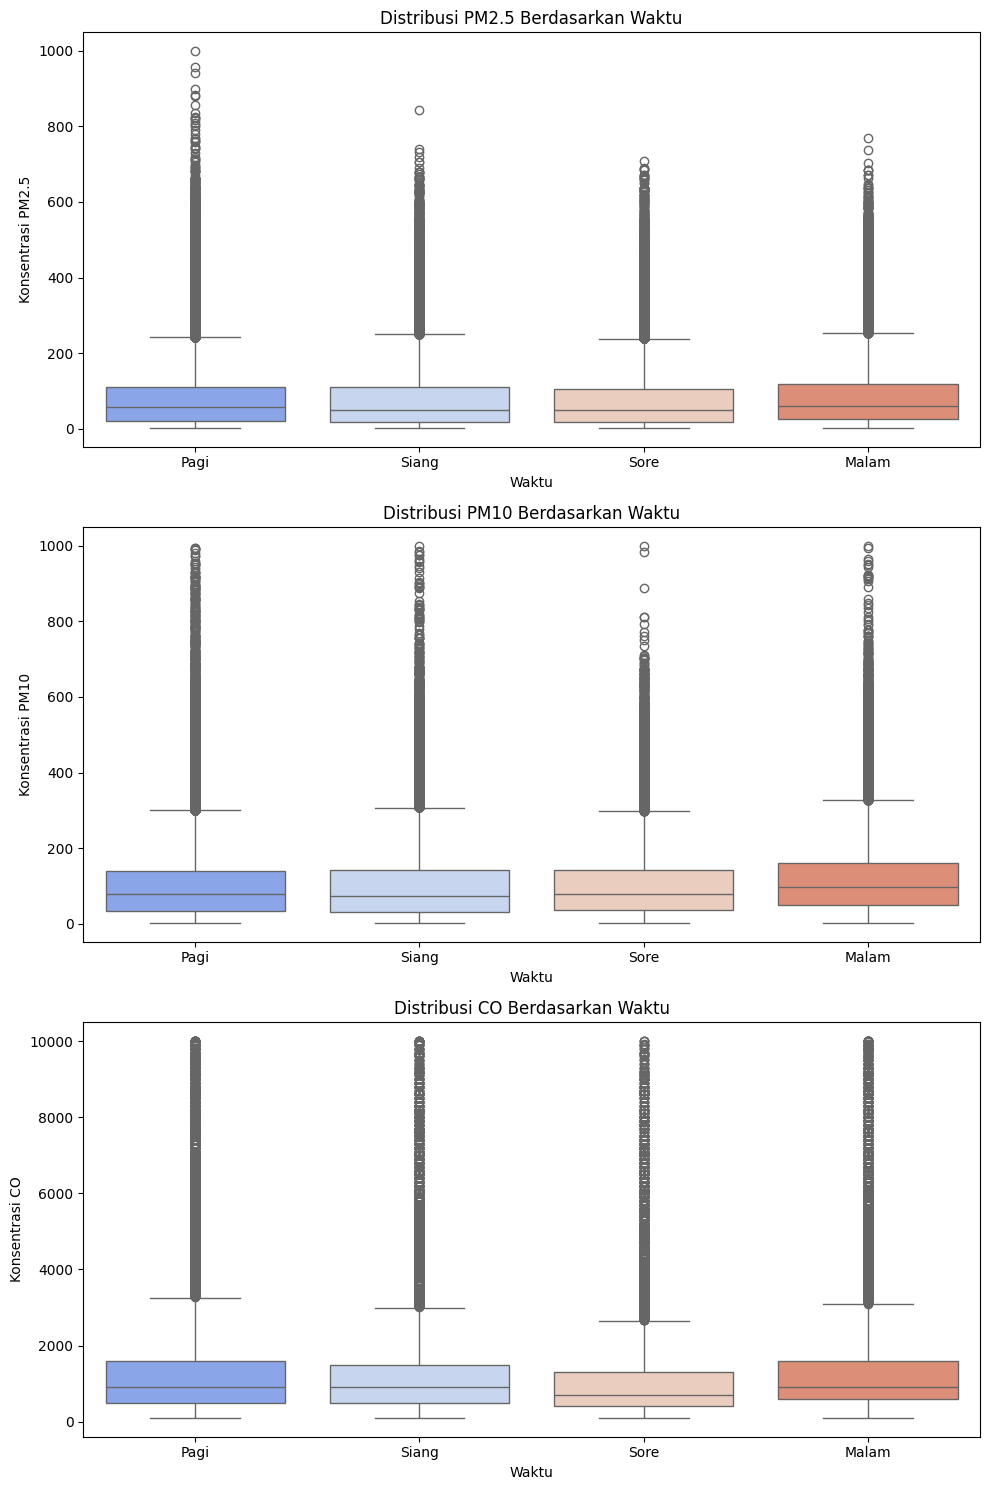

In [329]:
# 📌 Visualisasi dengan Boxplot
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

for i, polutan in enumerate(polutan_list):
    sns.boxplot(x="Waktu", y=polutan, data=df, ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"Distribusi {polutan} Berdasarkan Waktu")
    axes[i].set_xlabel("Waktu")
    axes[i].set_ylabel(f"Konsentrasi {polutan}")

plt.tight_layout()
plt.show()

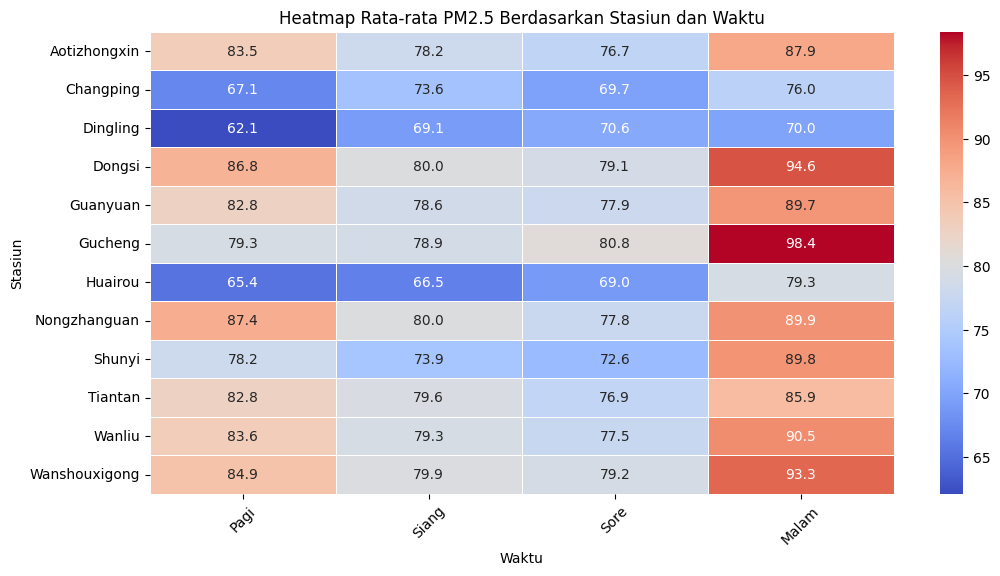

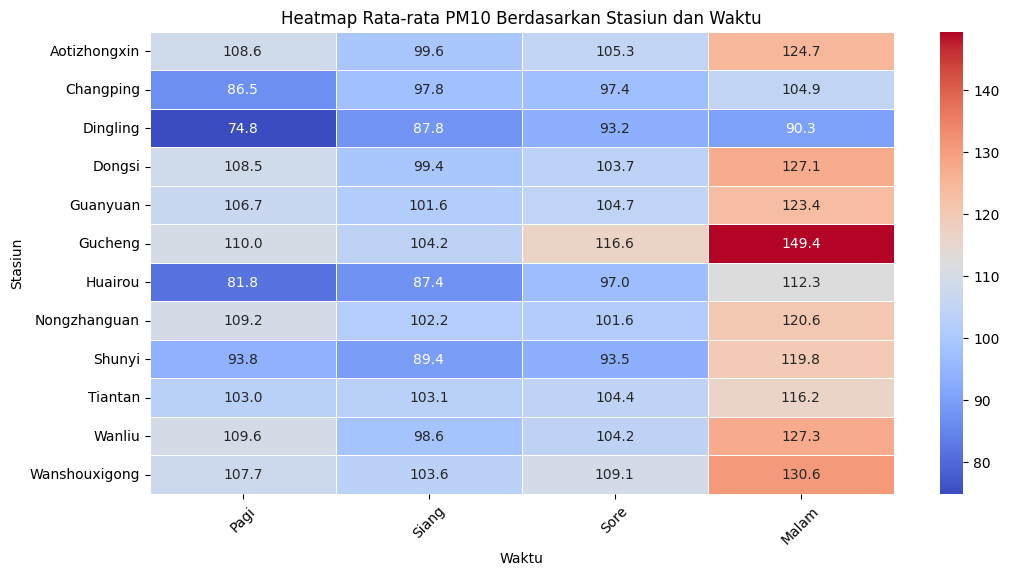

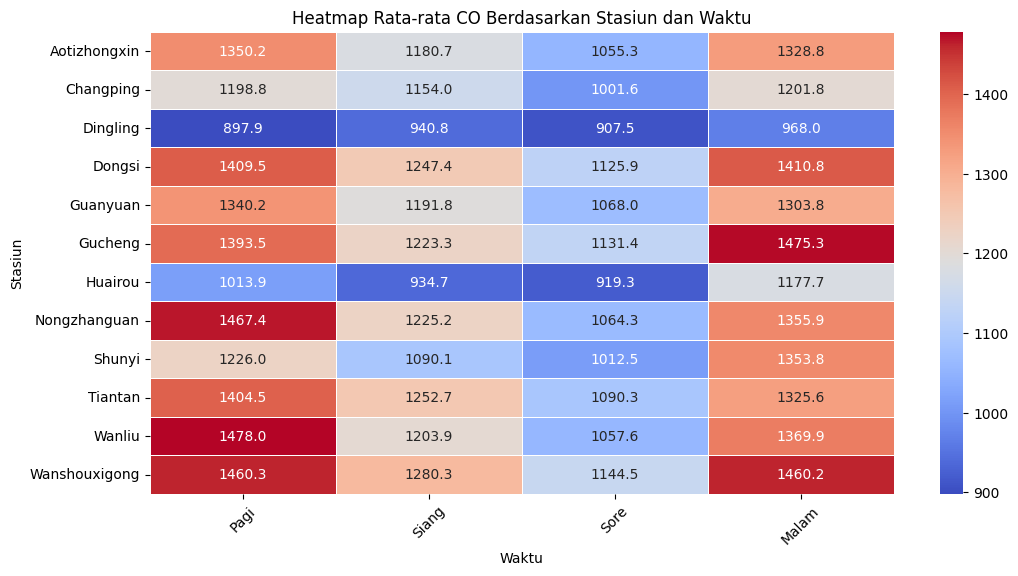

In [330]:
# 📌 Visualisasi dengan Heatmap
for polutan in polutan_list:
    df_pivot = df_grouped.pivot(index="station", columns="Waktu", values=polutan)

    plt.figure(figsize=(12, 6))
    sns.heatmap(df_pivot, cmap="coolwarm", annot=True, fmt=".1f", linewidths=0.5)
    plt.title(f"Heatmap Rata-rata {polutan} Berdasarkan Stasiun dan Waktu")
    plt.xlabel("Waktu")
    plt.ylabel("Stasiun")
    plt.xticks(rotation=45)
    plt.show()

## Conclusion

1. Conclution pertanyaan 1
    - Tren tahunan menunjukkan adanya fluktuasi dalam konsentrasi polutan.
    - Sebagian besar polutan (PM2.5, PM10, NO2, SO2, CO, O3) mengalami penurunan sekitar tahun dari 2014-2016, tetapi meningkat kembali pada tahun 2017.
2. Conclution pertanyaan 2
    - _Gucheng_ dan _Dongsi_ sering mencatatkan konsentrasi polutan yang lebih tinggi dibandingkan stasiun lainnya. 
    - _Huairou_ dan _Dingling_ memiliki tingkat polusi yang relatif lebih rendah.
3. Conclution Analisis Lanjutan
    - Tidak terdapat perbedaan yang signifikan dalam distribusi polusi PM2.5, PM10, dan CO berdasarkan kategori waktu (pagi, siang, sore, malam).
    - Konsentrasi polusi cenderung seragam sepanjang hari dengan beberapa outlier yang cukup tinggi.